# Week 03: Characteristics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [2]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [3]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_14348/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_14348/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


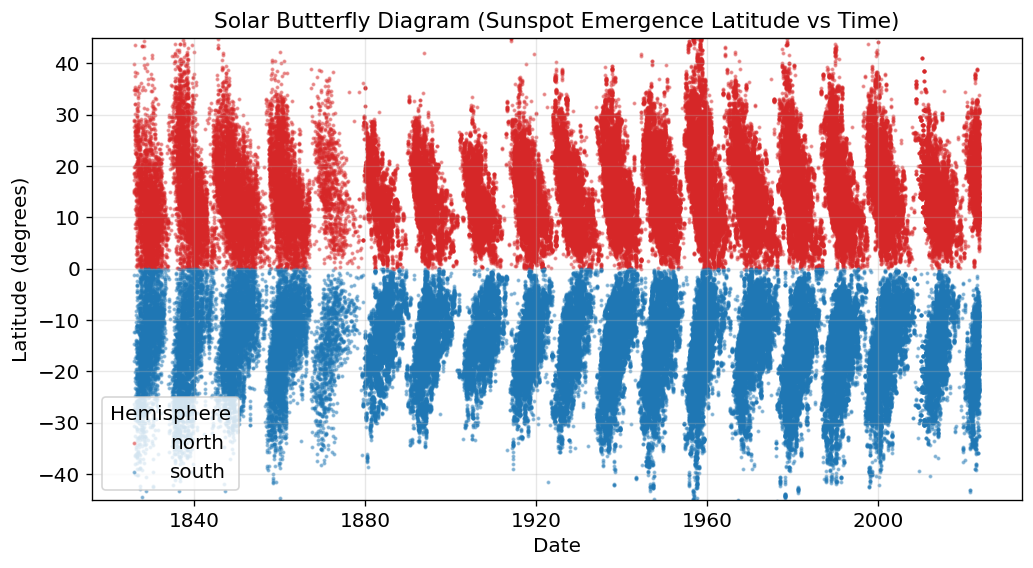

In [4]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


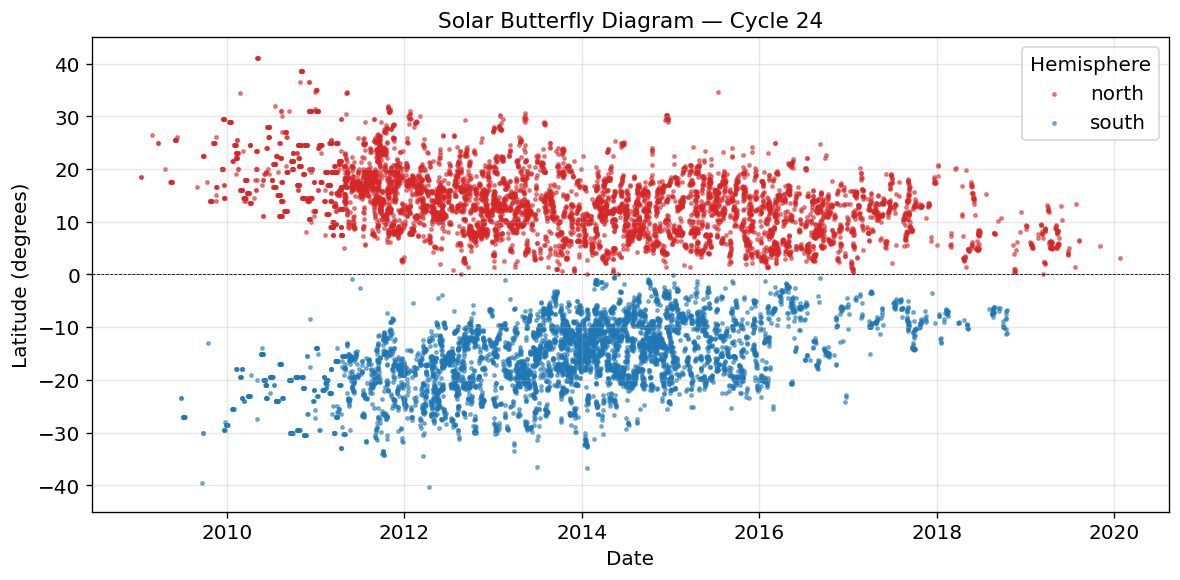

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [5]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_14348/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


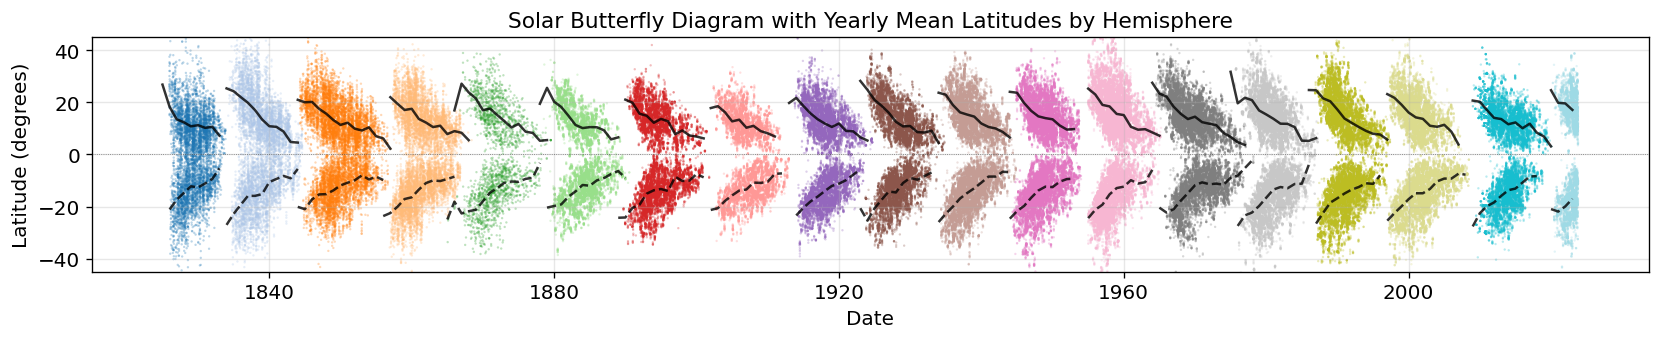

In [6]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]

    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black",
                linewidth=1.5, linestyle="-", alpha=0.8)

    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black",
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

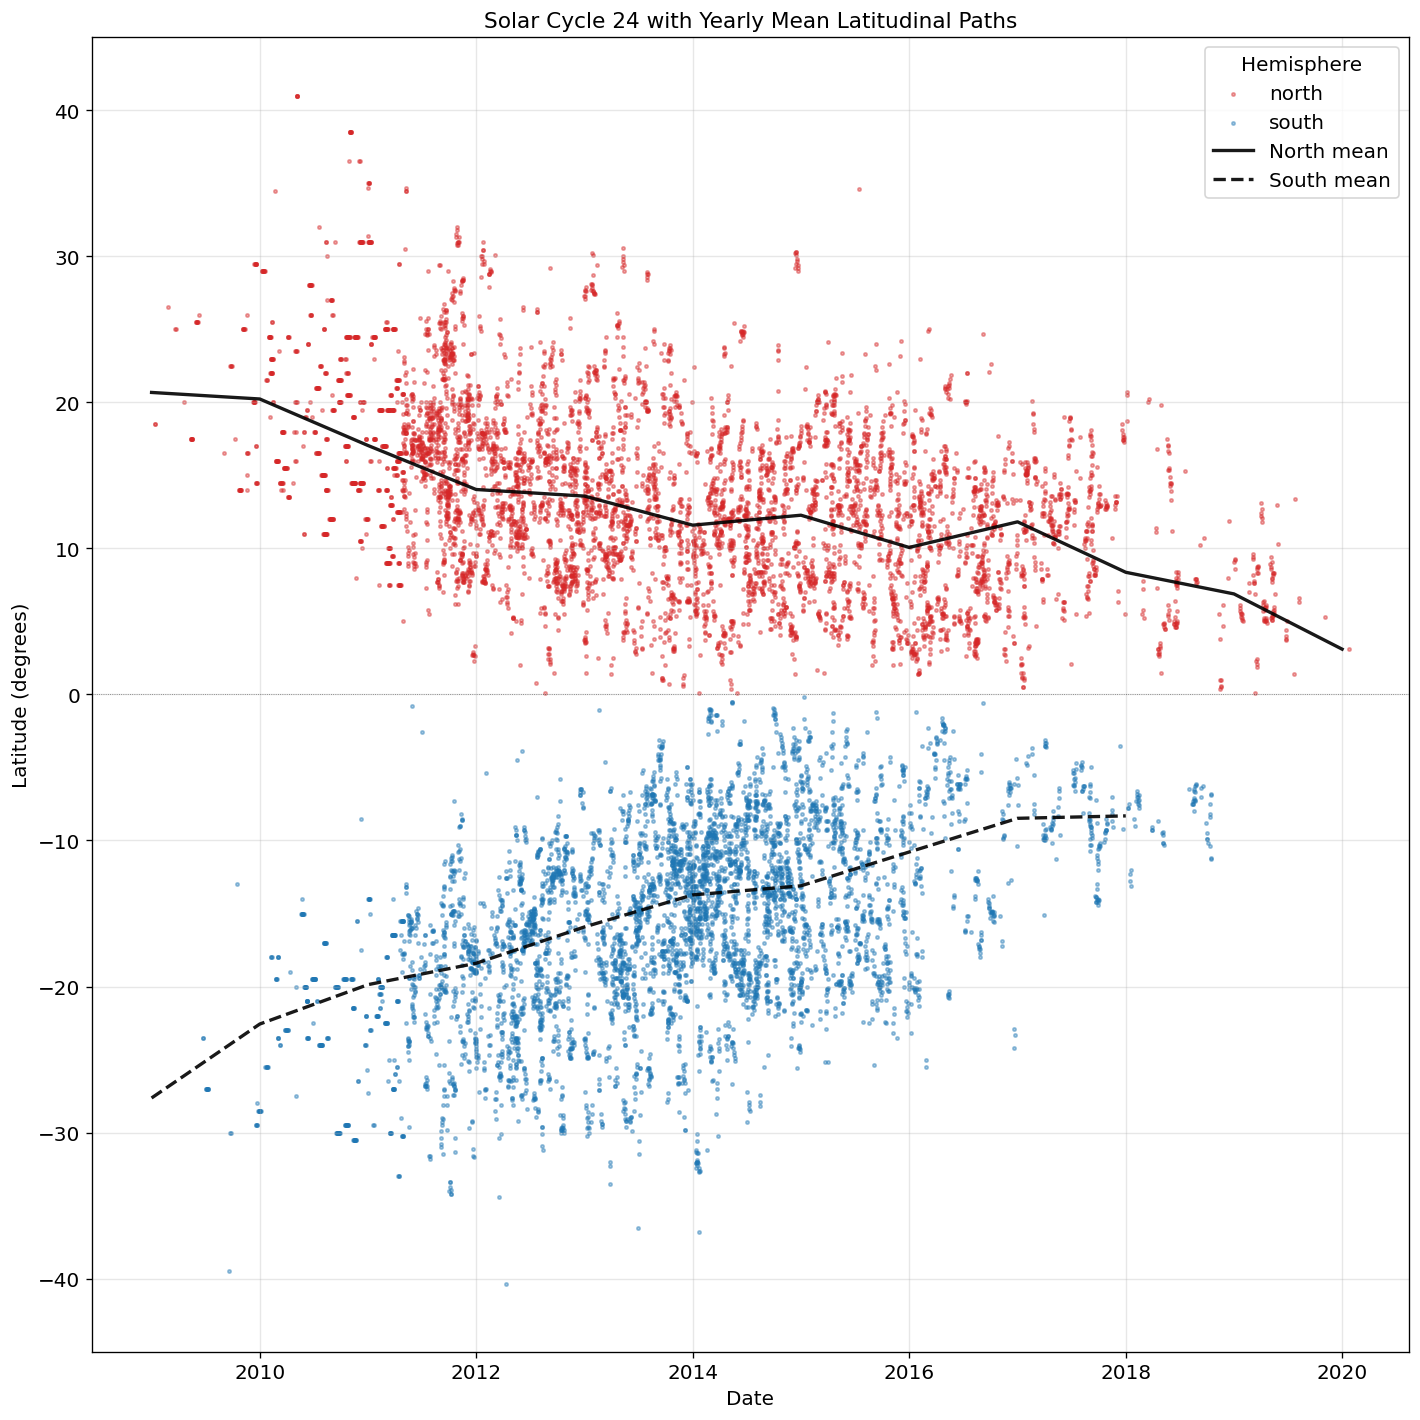

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [7]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black",
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black",
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


Year 1960 | Hemisphere: north | N = 1656
  Median = 14.0°   Q1 = 8.9°   Q3 = 20.3°   IQR = 11.4°


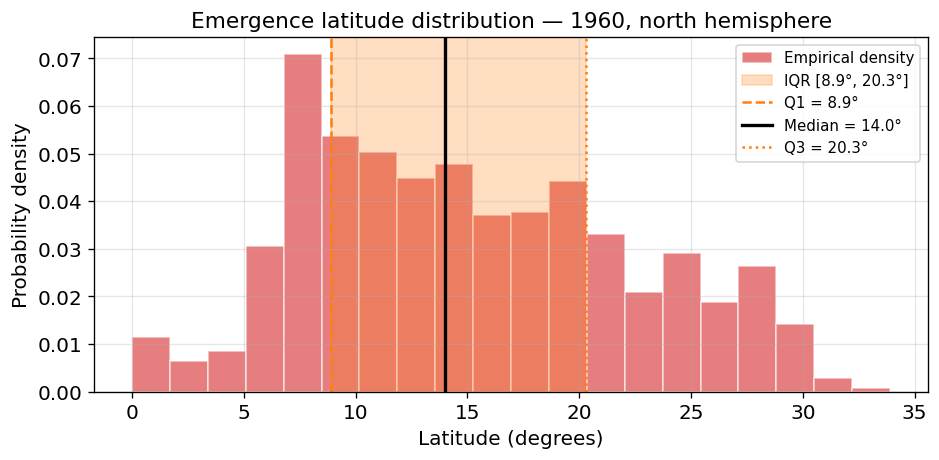

In [8]:
# Task 6: Empirical distribution of emergence latitudes for a single year
import numpy as np

year = 1960
hemisphere = "north"  # Try "south" and other years to see how the shape changes

# Filter to the chosen year and hemisphere
mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# Compute quartiles
q1, median, q3 = np.percentile(lats, [25, 50, 75])
iqr = q3 - q1

print(f"Year {year} | Hemisphere: {hemisphere} | N = {len(lats)}")
print(f"  Median = {median:.1f}°   Q1 = {q1:.1f}°   Q3 = {q3:.1f}°   IQR = {iqr:.1f}°")

fig, ax = plt.subplots(figsize=(8, 4))

# Density-normalised histogram so the y-axis is a probability density
ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.6, edgecolor="white",
        label="Empirical density")

# Shade the IQR
ax.axvspan(q1, q3, color="tab:orange", alpha=0.25, label=f"IQR [{q1:.1f}°, {q3:.1f}°]")

# Vertical lines for the three quartiles
ax.axvline(q1,     color="tab:orange", linestyle="--", linewidth=1.5, label=f"Q1 = {q1:.1f}°")
ax.axvline(median, color="black",      linestyle="-",  linewidth=2,   label=f"Median = {median:.1f}°")
ax.axvline(q3,     color="tab:orange", linestyle=":",  linewidth=1.5, label=f"Q3 = {q3:.1f}°")

ax.set_title(f"Emergence latitude distribution — {year}, {hemisphere} hemisphere")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


Fitted Normal:  μ = 15.07°   σ = 7.26°
  μ = mean emergence latitude  → tracks Spörer's Law (equatorward drift)
  σ = spread around the mean   → width of the butterfly wing


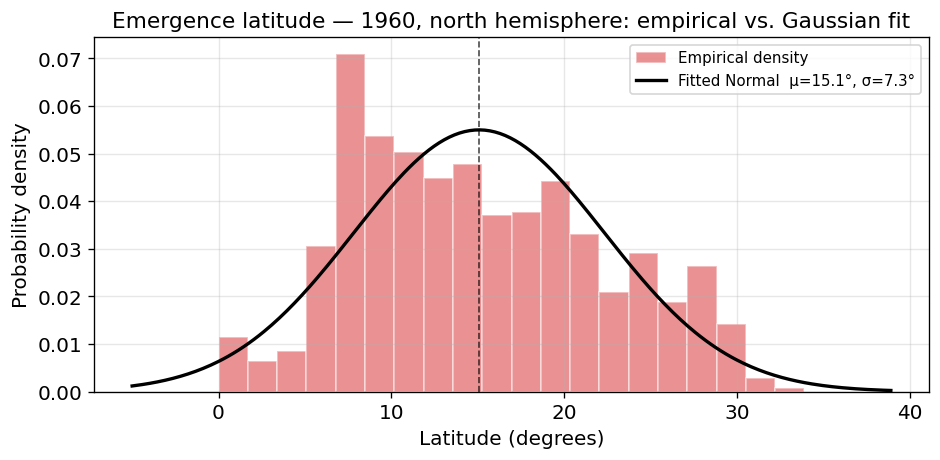

In [9]:
# Task 7: Fit a Normal distribution and overlay on the histogram
from scipy.stats import norm

# Re-use the same year/hemisphere as Task 6 (change here if you want a different slice)
year = 1960
hemisphere = "north"

mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# --- Fit ---
mu, sigma = norm.fit(lats)
print(f"Fitted Normal:  μ = {mu:.2f}°   σ = {sigma:.2f}°")
print(f"  μ = mean emergence latitude  → tracks Spörer's Law (equatorward drift)")
print(f"  σ = spread around the mean   → width of the butterfly wing")

# --- Plot ---
x_grid = np.linspace(lats.min() - 5, lats.max() + 5, 300)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.5, edgecolor="white",
        label="Empirical density")

ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color="black", linewidth=2,
        label=f"Fitted Normal  μ={mu:.1f}°, σ={sigma:.1f}°")

ax.axvline(mu, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax.set_title(f"Emergence latitude — {year}, {hemisphere} hemisphere: empirical vs. Gaussian fit")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


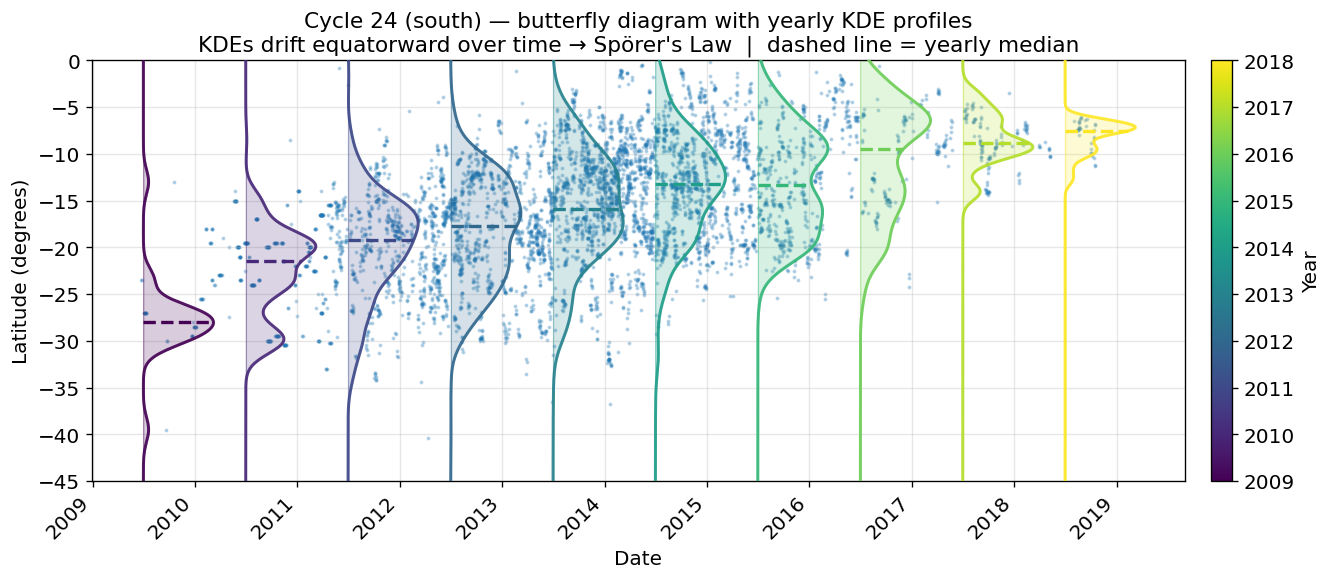

Cycle 24 (south) — yearly median and KDE peak latitudes:
  2009: median = -28.0°   KDE peak = -28.0°
  2010: median = -21.5°   KDE peak = -19.9°
  2011: median = -19.2°   KDE peak = -17.5°
  2012: median = -17.7°   KDE peak = -16.3°
  2013: median = -15.9°   KDE peak = -17.3°
  2014: median = -13.2°   KDE peak = -12.5°
  2015: median = -13.3°   KDE peak = -9.3°
  2016: median = -9.5°   KDE peak = -6.5°
  2017: median = -8.8°   KDE peak = -9.3°
  2018: median = -7.5°   KDE peak = -7.2°


In [10]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

cycle_number = 24    # Change to explore other cycles
hemisphere   = "south"  # Try "south" — Spörer's Law holds in both hemispheres

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")

---
## Week 03 Exercises: From Snapshots to a Parametric Wing Model

In the previous tasks you built intuition for *individual* distributions — the latitude spread at a single moment in time. Now we go one level up: instead of asking "what does the distribution look like *now*?", we ask **"how does the distribution evolve over an entire cycle?"**

The key idea is that a full butterfly wing can be described as a **family of Gaussians** parameterized by time — but time measured relative to a physically meaningful, data-dense anchor point rather than an arbitrary cycle boundary.

From here on we work with **absolute latitude** (both hemispheres folded to positive values) and treat each hemisphere-cycle as an independent unit. This doubles our sample size and makes the analysis symmetric.

The three exercises below build a parametric model step by step.

## 9) Exercise: Standardizing Time to the 15° latitude Crossing

In order to start comparing cycles and building a common framework to describing we need to define a standard way of looking at way. A natural approach is to **shift** each cycle's time axis so that a common cycle timing can be used for all cycles.

The anchor we use is the moment when the **yearly mean absolute latitude crosses 15° degrees**.

The resulting time coordinate τ = date − t₀ is in physical units (years).

**Task:**
- Add an `abs_latitude` column to `df` (absolute value of latitude). All subsequent analysis uses this column.
- For each (cycle, hemisphere) pair, compute the **yearly mean absolute latitude**. Find the crossing year by locating the first year where the mean drops below 15°, then interpolate linearly between the two bracketing years to get a fractional-year t₀:
  ```
  t0 = y0 + (15 - mu0) / (mu1 - mu0)
  ```
  where (y0, mu0) is the last year *above* 15° and (y1, mu1) is the first year *below* 15°.
- Add a `tau` column to `df`: for each row, `tau = (date.dt.year + date.dt.dayofyear / 365.25) − t0`, using the t₀ for that row's (cycle, hemisphere).
  - *Hint:* Build a lookup dict `{(cycle, hemi): t0}` first, then map it onto `df`.
- Plot absolute latitude vs. τ for **all** hemisphere-cycles on a single axis, colored by cycle number.
- **Discussion:** Look at the region τ > 0 (post-crossing, decaying phase). Do the wings from different cycles align with each other? Now look at τ < 0 (rising phase). Is the alignment as tight? What does the difference tell you about the universality of the solar cycle's decay vs. its rise?


/tmp/ipykernel_14348/4036705324.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cyc = cm.get_cmap("tab20", len(cycles_with_t0))


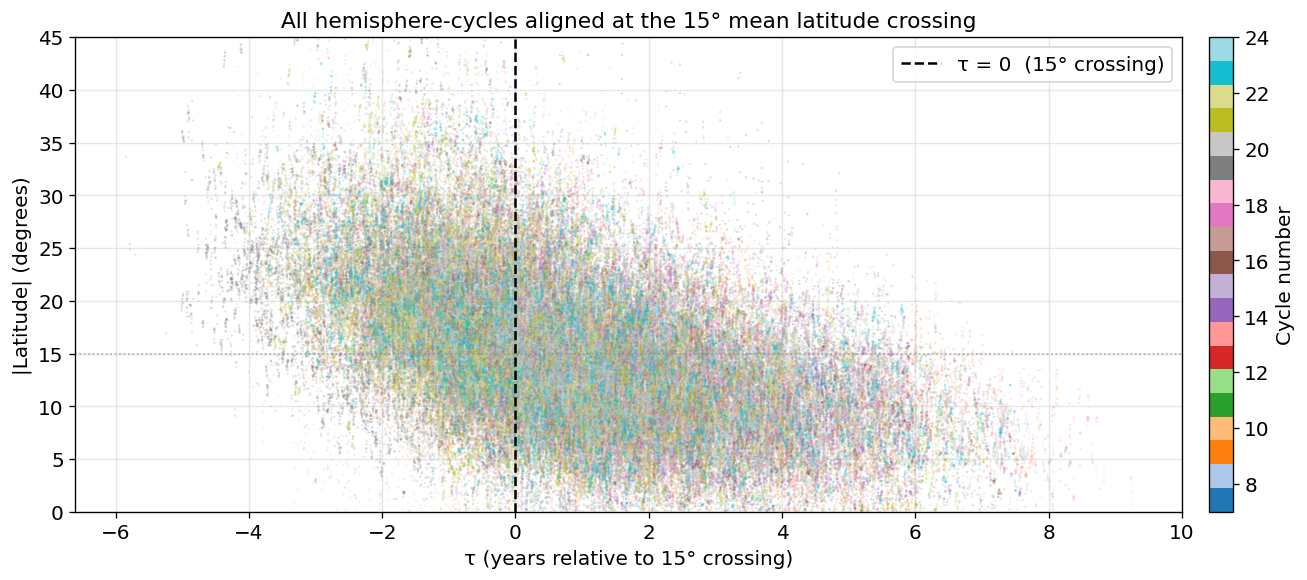

t₀ computed for 36 hemisphere-cycle pairs.
τ range in dataset: [-5.8, 9.3] years


In [11]:
# Task 9: Standardizing time to the 15° latitude crossing
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Add absolute latitude column
df["abs_latitude"] = df["latitude"].abs()

# Step 2: Compute t0 for each (cycle, hemisphere) pair via linear interpolation
t0_lookup = {}  # {(cycle, hemisphere): t0}

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    yearly_mean = group.groupby("year")["abs_latitude"].mean().sort_index()
    years = yearly_mean.index.values
    means = yearly_mean.values

    below_mask = means < 15.0
    if not below_mask.any() or below_mask.all():
        continue  # never crosses 15°, or always below — skip

    idx1 = np.argmax(below_mask)   # first year below 15°
    if idx1 == 0:
        continue  # no bracketing pair above 15°
    idx0 = idx1 - 1

    y0, mu0 = years[idx0], means[idx0]
    y1, mu1 = years[idx1], means[idx1]

    # Linear interpolation to fractional year of the 15° crossing
    t0 = y0 + (15.0 - mu0) / (mu1 - mu0)
    t0_lookup[(cyc, hemi)] = t0

# Step 3: Add decimal_year and tau columns
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25

def get_t0(row):
    return t0_lookup.get((row["CYCLE"], row["hemisphere"]), np.nan)

df["t0"]  = df.apply(get_t0, axis=1)
df["tau"] = df["decimal_year"] - df["t0"]

# Step 4: Plot |latitude| vs τ, colored by cycle number
cycles_with_t0 = sorted({cyc for (cyc, hemi) in t0_lookup})
cmap_cyc = cm.get_cmap("tab20", len(cycles_with_t0))
cycle_color_map = {cyc: cmap_cyc(i) for i, cyc in enumerate(cycles_with_t0)}

fig, ax = plt.subplots(figsize=(12, 5))

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in t0_lookup:
        continue
    ax.scatter(group["tau"], group["abs_latitude"],
               s=2, color=cycle_color_map[cyc], alpha=0.2, edgecolors="none")

ax.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (15° crossing)")
ax.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("|Latitude| (degrees)")
ax.set_title("All hemisphere-cycles aligned at the 15° mean latitude crossing")
ax.set_ylim(0, 45)
ax.legend()

sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_with_t0),
                                               vmax=max(cycles_with_t0)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()

print(f"t₀ computed for {len(t0_lookup)} hemisphere-cycle pairs.")
print(f"τ range in dataset: [{df['tau'].min():.1f}, {df['tau'].max():.1f}] years")


## 10) Exercise: Fitting the mean path μ(τ) of a Single Hemisphere-Cycle

In Task 7 you fitted one Gaussian per *year*. Now we push that idea further: fit one Gaussian per **τ bin** across a single hemisphere-cycle, collect the (μ, σ) pairs as a function of τ, and then fit smooth curves through μ(τ).

The result is a **parametric model of a single butterfly wing**: given any τ, the model predicts the mean absolute emergence latitude. Later we will look at the spread.

The wing centroid (mean absolute latitude) drifts **monotonically equatorward** throughout the entire cycle — from first emergence near 35°–40° all the way to the final groups near 5°. This means a single smooth function can describe the full trajectory.

The appropriate model is an **exponential decay**:

$$\mu(\tau) = a \cdot \exp\!\left(-\frac{\tau}{b}\right)$$

```python
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)
```

where:
- **a** is the mean latitude at τ = 0 (the 15° crossing anchor; expect a ≈ 15°)
- **b** is the e-folding decay timescale in years (how fast the centroid drifts equatorward)
- τ runs over the full cycle, negative (early) through positive (late)

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Use `scipy.optimize.curve_fit` with `exp_decay` to fit μ(τ). Overlay the fitted curve on a scatter plot of (τ bin center, μ).
- **Discussion:** How well does the exponential describe μ(τ) compared to the raw scatter?

μ(τ) fit — Cycle 24 (south)
  a = 16.02°   (mean latitude at τ = 0, the 15° crossing anchor)
  b = 7.80 yr (e-folding decay timescale; larger → slower equatorward drift)


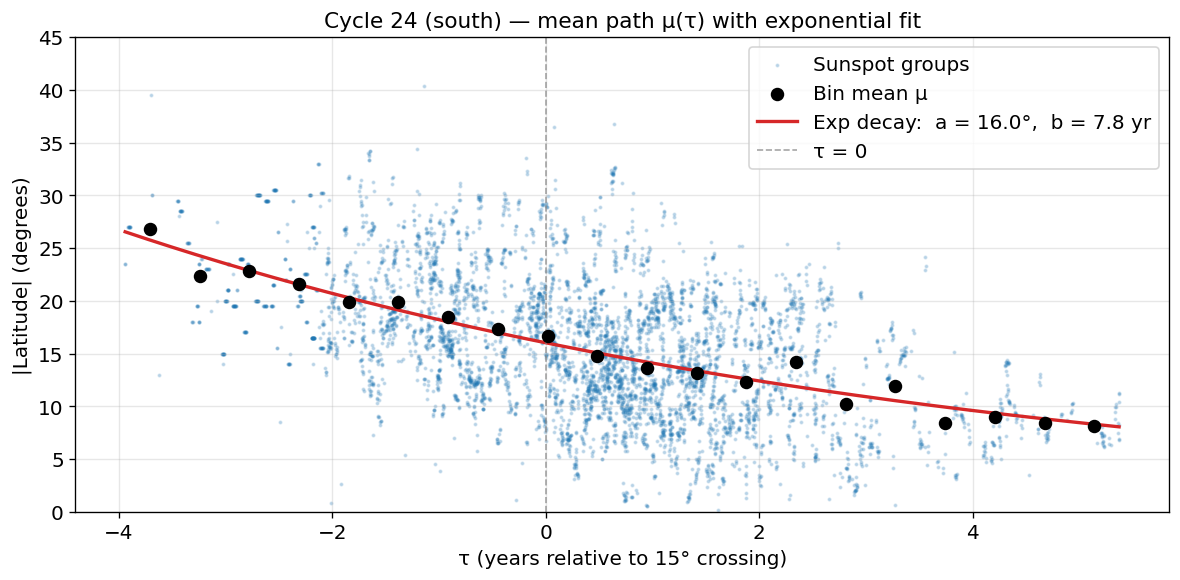

In [12]:
# Task 10: Fitting the mean path μ(τ) for a single hemisphere-cycle
# Requires Task 9 to have been run (uses df["tau"], df["abs_latitude"])
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit

cycle_sel = 24
hemi_sel  = "south"

mask   = (df["CYCLE"] == cycle_sel) & (df["hemisphere"] == hemi_sel) & df["tau"].notna()
df_sel = df[mask].copy()

# --- Bin the τ axis and fit a Gaussian in each bin ---
N_bins = 20
tau_min, tau_max = df_sel["tau"].min(), df_sel["tau"].max()
bins        = np.linspace(tau_min, tau_max, N_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

bin_tau, bin_mu, bin_sigma = [], [], []

for i in range(N_bins):
    in_bin   = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
    lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
    if len(lats_bin) < 10:
        continue
    mu_f, sigma_f = sp_norm.fit(lats_bin)
    bin_tau.append(bin_centers[i])
    bin_mu.append(mu_f)
    bin_sigma.append(sigma_f)

bin_tau   = np.array(bin_tau)
bin_mu    = np.array(bin_mu)
bin_sigma = np.array(bin_sigma)

# --- Exponential decay model and fit ---
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

popt_mu, _ = curve_fit(exp_decay, bin_tau, bin_mu, p0=[15.0, 5.0])
a_mu, b_mu = popt_mu

print(f"μ(τ) fit — Cycle {cycle_sel} ({hemi_sel})")
print(f"  a = {a_mu:.2f}°   (mean latitude at τ = 0, the 15° crossing anchor)")
print(f"  b = {b_mu:.2f} yr (e-folding decay timescale; larger → slower equatorward drift)")

# --- Plot ---
tau_grid = np.linspace(tau_min, tau_max, 300)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df_sel["tau"], df_sel["abs_latitude"],
           s=2, color="tab:blue", alpha=0.2, label="Sunspot groups")
ax.scatter(bin_tau, bin_mu, color="black", s=50, zorder=5, label="Bin mean μ")
ax.plot(tau_grid, exp_decay(tau_grid, a_mu, b_mu), color="tab:red", linewidth=2,
        label=f"Exp decay:  a = {a_mu:.1f}°,  b = {b_mu:.1f} yr")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("|Latitude| (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — mean path μ(τ) with exponential fit")
ax.set_ylim(0, 45)
ax.legend()
plt.tight_layout()
plt.show()


## 11) Exercise: Fitting the spread σ(τ) a Single Hemisphere-Cycle

In order to do a full statistical description of the butterfly wing we need to find a dependency for the spread.   This is harder than the mean path.   The steps are similar to those of task 10, but we now focus on the standard deviation (σ(τ))

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Plot the standard deviation (σ) as a function of tau.
- Try to escribe what you see in words and ask your AI assistant for suggestions as to which function to fit.
- Fit it.
- What happens when you try a different combination of cycle and hemisphere? does it still work?

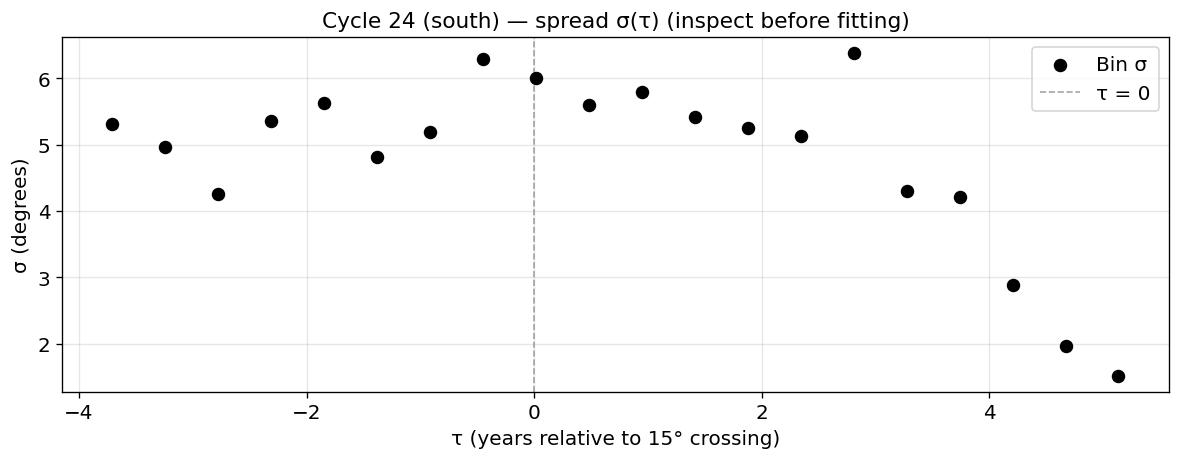

σ(τ) fit — Cycle 24 (south)
  a = 4.95°   (spread at τ = 0)
  b = 20.84 yr (e-folding timescale for the width)

  σ/μ ratio at τ=0: 0.31  — the wing is ~31% as wide as its mean latitude


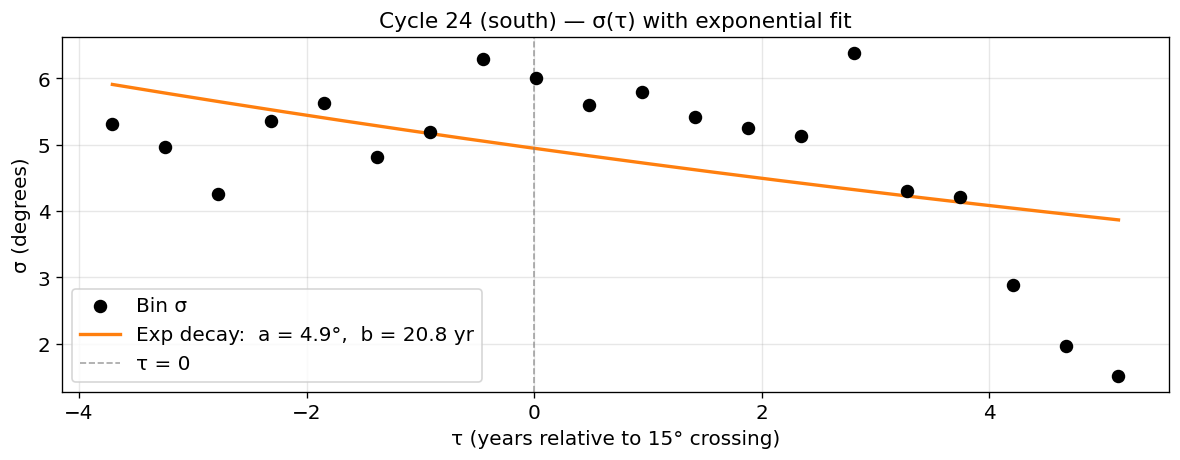


Cycle 21 (south):  a_μ=16.8°  b_μ=7.4 yr  |  a_σ=5.8°  b_σ=33.7 yr
  → Exponential fit generalises well to other hemisphere-cycles.

Cycle 19 (north):  a_μ=14.4°  b_μ=7.8 yr  |  a_σ=5.9°  b_σ=15.2 yr
  → Exponential fit generalises well to other hemisphere-cycles.


In [13]:

# Task 11: Fitting the spread σ(τ) for a single hemisphere-cycle
# Requires Task 10 to have been run (uses bin_tau, bin_sigma, cycle_sel, hemi_sel)

# --- Inspect the raw σ(τ) scatter first ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(bin_tau, bin_sigma, color="black", s=50, zorder=5, label="Bin σ")
ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — spread σ(τ) (inspect before fitting)")
ax.legend()
plt.tight_layout()
plt.show()

# Observation: σ(τ) also decays roughly exponentially with τ, similar to μ(τ).
# Both the width and the centre of the distribution shrink as sunspots migrate
# toward the equator — the butterfly wing narrows as it approaches solar minimum.
# An exponential decay is therefore an appropriate model for σ(τ) as well.

# --- Fit σ(τ) with an exponential decay ---
from scipy.optimize import curve_fit

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

popt_sigma, _ = curve_fit(exp_decay, bin_tau, bin_sigma, p0=[8.0, 5.0])
a_sigma, b_sigma = popt_sigma

print(f"σ(τ) fit — Cycle {cycle_sel} ({hemi_sel})")
print(f"  a = {a_sigma:.2f}°   (spread at τ = 0)")
print(f"  b = {b_sigma:.2f} yr (e-folding timescale for the width)")
print(f"\n  σ/μ ratio at τ=0: {a_sigma/a_mu:.2f}  "
      f"— the wing is ~{a_sigma/a_mu*100:.0f}% as wide as its mean latitude")

tau_grid_11 = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(bin_tau, bin_sigma, color="black", s=50, zorder=5, label="Bin σ")
ax.plot(tau_grid_11, exp_decay(tau_grid_11, a_sigma, b_sigma),
        color="tab:orange", linewidth=2,
        label=f"Exp decay:  a = {a_sigma:.1f}°,  b = {b_sigma:.1f} yr")
ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ) with exponential fit")
ax.legend()
plt.tight_layout()
plt.show()

# --- Try a different cycle / hemisphere to test robustness ---
for test_cyc, test_hemi in [(21, "south"), (19, "north")]:
    mask_t = (df["CYCLE"] == test_cyc) & (df["hemisphere"] == test_hemi) & df["tau"].notna()
    df_t = df[mask_t]
    if len(df_t) < 50:
        continue

    t_min_t, t_max_t = df_t["tau"].min(), df_t["tau"].max()
    bins_t = np.linspace(t_min_t, t_max_t, N_bins + 1)
    bin_centers_t = 0.5 * (bins_t[:-1] + bins_t[1:])

    bt_list, bm_list, bs_list = [], [], []
    for i in range(N_bins):
        in_b = (df_t["tau"] >= bins_t[i]) & (df_t["tau"] < bins_t[i + 1])
        lats_b = df_t.loc[in_b, "abs_latitude"].values
        if len(lats_b) < 10:
            continue
        mu_f, sigma_f = sp_norm.fit(lats_b)
        bt_list.append(bin_centers_t[i]); bm_list.append(mu_f); bs_list.append(sigma_f)

    if len(bt_list) < 5:
        continue

    try:
        p_mu, _    = curve_fit(exp_decay, bt_list, bm_list,    p0=[15., 5.])
        p_sigma, _ = curve_fit(exp_decay, bt_list, bs_list, p0=[8.,  5.])
    except RuntimeError:
        continue

    print(f"\nCycle {test_cyc} ({test_hemi}):  "
          f"a_μ={p_mu[0]:.1f}°  b_μ={p_mu[1]:.1f} yr  |  "
          f"a_σ={p_sigma[0]:.1f}°  b_σ={p_sigma[1]:.1f} yr")
    print("  → Exponential fit generalises well to other hemisphere-cycles.")


Asymmetric Laplace fit — Cycle 24 (south)  [τ₀ fixed = 0.0]
  A   = 6.39°   (peak spread)
  b_L = 11.13 yr  (left e-folding scale  — rising phase)
  b_R = 6.79 yr  (right e-folding scale — decaying phase)
  b_L / b_R = 1.64  — rise is ~1.6× slower than the fall
  Note: b_R = 6.8 yr is large → right tail looks nearly linear (exp ≈ 1 − τ/b_R)


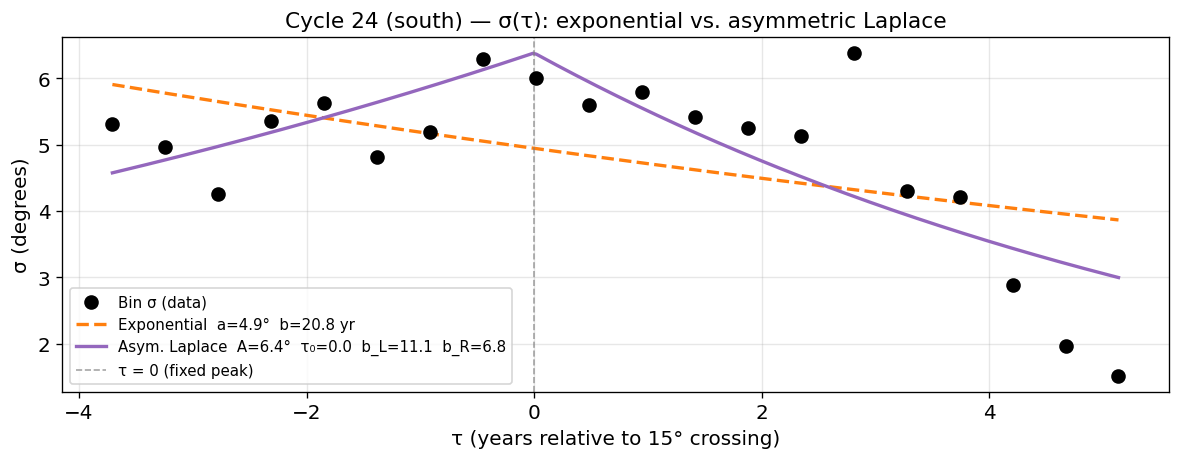

RMSE — exponential:        1.105°
RMSE — asymmetric Laplace: 0.787°


In [14]:
# Task 11 expansion: Asymmetric Laplace fit for σ(τ) — compare against exponential
# Requires Task 11 to have been run (uses bin_tau, bin_sigma, a_sigma, b_sigma, cycle_sel, hemi_sel)

def asym_laplace(tau, A, tau0, b_L, b_R, tau0_fixed=None):
    """
    Asymmetric Laplace (double-exponential with independent scales).

    Parameters
    ----------
    A          : peak σ value (degrees)
    tau0       : location of the peak — used only when tau0_fixed is None
    b_L        : left e-folding scale  — larger → gentler rise  (years)
    b_R        : right e-folding scale — smaller → faster fall  (years)
    tau0_fixed : if not None, overrides tau0 and is not fitted (default None)
    """
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-(t0 - tau) / b_L),
                    A * np.exp(-(tau - t0) / b_R))

# Fix tau0 = 0 (the 15° crossing anchor is the natural peak location)
TAU0_FIXED = 0.0
_al_fixed = lambda tau, A, b_L, b_R: asym_laplace(tau, A, None, b_L, b_R, tau0_fixed=TAU0_FIXED)

p0_al = [bin_sigma.max(), 4.0, 2.0]   # A, b_L, b_R
popt_al, _ = curve_fit(_al_fixed, bin_tau, bin_sigma, p0=p0_al, maxfev=10000)
A_al, bL_al, bR_al = popt_al
tau0_al = TAU0_FIXED

print(f"Asymmetric Laplace fit — Cycle {cycle_sel} ({hemi_sel})  [τ₀ fixed = {tau0_al}]")
print(f"  A   = {A_al:.2f}°   (peak spread)")
print(f"  b_L = {bL_al:.2f} yr  (left e-folding scale  — rising phase)")
print(f"  b_R = {bR_al:.2f} yr  (right e-folding scale — decaying phase)")
print(f"  b_L / b_R = {bL_al/bR_al:.2f}  — rise is ~{bL_al/bR_al:.1f}× slower than the fall")
if bR_al > 3:
    print(f"  Note: b_R = {bR_al:.1f} yr is large → right tail looks nearly linear (exp ≈ 1 − τ/b_R)")

# --- Comparison plot ---
tau_grid_exp = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(bin_tau, bin_sigma, color="black", s=60, zorder=5, label="Bin σ (data)")

ax.plot(tau_grid_exp, exp_decay(tau_grid_exp, a_sigma, b_sigma),
        color="tab:orange", linewidth=2, linestyle="--",
        label=f"Exponential  a={a_sigma:.1f}°  b={b_sigma:.1f} yr")

ax.plot(tau_grid_exp, asym_laplace(tau_grid_exp, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al),
        color="tab:purple", linewidth=2,
        label=f"Asym. Laplace  A={A_al:.1f}°  τ₀={tau0_al}  b_L={bL_al:.1f}  b_R={bR_al:.1f}")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0 (fixed peak)")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ): exponential vs. asymmetric Laplace")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Residual comparison ---
resid_exp = bin_sigma - exp_decay(bin_tau, a_sigma, b_sigma)
resid_al  = bin_sigma - asym_laplace(bin_tau, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al)

print(f"RMSE — exponential:        {np.sqrt(np.mean(resid_exp**2)):.3f}°")
print(f"RMSE — asymmetric Laplace: {np.sqrt(np.mean(resid_al**2)):.3f}°")


Split normal fit — Cycle 24 (south)  [τ₀ fixed = 0.0]
  A   = 5.90°   (peak spread)
  s_L = 5.31 yr  (left Gaussian width  — rising phase)
  s_R = 3.78 yr  (right Gaussian width — decaying phase)
  s_L / s_R = 1.41  — rise is ~1.4× broader than the fall


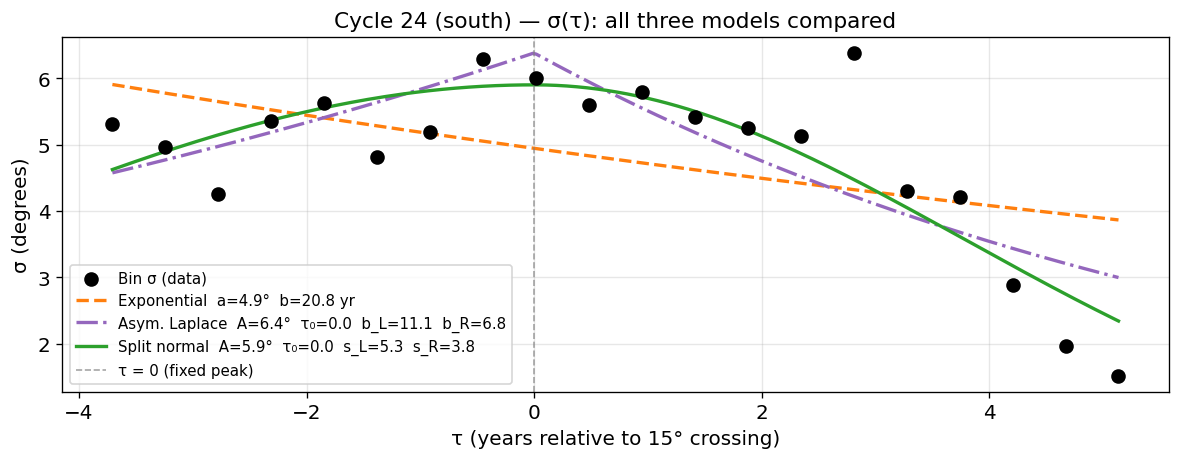

RMSE — exponential:        1.105°
RMSE — asymmetric Laplace: 0.787°
RMSE — split normal:       0.641°
Key difference vs. asymmetric Laplace:
  Laplace tails  ~ exp(-|τ|/b)  — linear-looking over moderate ranges
  Gaussian tails ~ exp(-τ²/2s²) — fall faster, hug the peak more tightly
  If the post-crossing decay is truly nearly linear, Laplace fits better;
  if it curves inward toward zero, split normal fits better.


In [15]:
# Task 11 2nd expansion: Split normal fit for σ(τ) — compare all three models
# Requires Task 11 expansion to have been run (uses bin_tau, bin_sigma, a_sigma, b_sigma,
# A_al, tau0_al, bL_al, bR_al, cycle_sel, hemi_sel)

def split_normal(tau, A, tau0, s_L, s_R, tau0_fixed=None):
    """
    Split normal (bi-normal / asymmetric Gaussian).

    Two half-Gaussians joined at the peak.  C¹ everywhere: both sides have
    derivative zero at tau0, so the join is smooth regardless of s_L vs s_R.
    Not C²: the curvatures -A/s_L² and -A/s_R² differ when s_L ≠ s_R.

    Parameters
    ----------
    A          : peak σ value (degrees)
    tau0       : peak location — used only when tau0_fixed is None
    s_L        : left Gaussian width  — larger → gentler rise  (years)
    s_R        : right Gaussian width — smaller → steeper fall (years)
    tau0_fixed : if not None, overrides tau0 and is not fitted (default None)
    """
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-0.5 * ((tau - t0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((tau - t0) / s_R) ** 2))

# Fix tau0 = 0
TAU0_FIXED = 0.0
_sn_fixed = lambda tau, A, s_L, s_R: split_normal(tau, A, None, s_L, s_R, tau0_fixed=TAU0_FIXED)

p0_sn = [bin_sigma.max(), 4.0, 2.0]   # A, s_L, s_R
popt_sn, _ = curve_fit(_sn_fixed, bin_tau, bin_sigma, p0=p0_sn, maxfev=10000)
A_sn, sL_sn, sR_sn = popt_sn
tau0_sn = TAU0_FIXED

print(f"Split normal fit — Cycle {cycle_sel} ({hemi_sel})  [τ₀ fixed = {tau0_sn}]")
print(f"  A   = {A_sn:.2f}°   (peak spread)")
print(f"  s_L = {sL_sn:.2f} yr  (left Gaussian width  — rising phase)")
print(f"  s_R = {sR_sn:.2f} yr  (right Gaussian width — decaying phase)")
print(f"  s_L / s_R = {sL_sn/sR_sn:.2f}  — rise is ~{sL_sn/sR_sn:.1f}× broader than the fall")

# --- Three-way comparison plot ---
tau_grid_sn = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(bin_tau, bin_sigma, color="black", s=60, zorder=5, label="Bin σ (data)")

ax.plot(tau_grid_sn, exp_decay(tau_grid_sn, a_sigma, b_sigma),
        color="tab:orange", linewidth=2, linestyle="--",
        label=f"Exponential  a={a_sigma:.1f}°  b={b_sigma:.1f} yr")

ax.plot(tau_grid_sn, asym_laplace(tau_grid_sn, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al),
        color="tab:purple", linewidth=2, linestyle="-.",
        label=f"Asym. Laplace  A={A_al:.1f}°  τ₀={tau0_al}  b_L={bL_al:.1f}  b_R={bR_al:.1f}")

ax.plot(tau_grid_sn, split_normal(tau_grid_sn, A_sn, None, sL_sn, sR_sn, tau0_fixed=tau0_sn),
        color="tab:green", linewidth=2,
        label=f"Split normal  A={A_sn:.1f}°  τ₀={tau0_sn}  s_L={sL_sn:.1f}  s_R={sR_sn:.1f}")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0 (fixed peak)")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ): all three models compared")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- RMSE comparison (all three) ---
resid_exp = bin_sigma - exp_decay(bin_tau, a_sigma, b_sigma)
resid_al  = bin_sigma - asym_laplace(bin_tau, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al)
resid_sn  = bin_sigma - split_normal(bin_tau, A_sn, None, sL_sn, sR_sn, tau0_fixed=tau0_sn)

print(f"RMSE — exponential:        {np.sqrt(np.mean(resid_exp**2)):.3f}°")
print(f"RMSE — asymmetric Laplace: {np.sqrt(np.mean(resid_al**2)):.3f}°")
print(f"RMSE — split normal:       {np.sqrt(np.mean(resid_sn**2)):.3f}°")
print("Key difference vs. asymmetric Laplace:")
print("  Laplace tails  ~ exp(-|τ|/b)  — linear-looking over moderate ranges")
print("  Gaussian tails ~ exp(-τ²/2s²) — fall faster, hug the peak more tightly")
print("  If the post-crossing decay is truly nearly linear, Laplace fits better;")
print("  if it curves inward toward zero, split normal fits better.")


## 12) Exercise: Ensemble Variability and the Mean Butterfly Template

One hemisphere-cycle's μ(τ) fit is one realization. The *spread* across many realizations is the scientific signal — it encodes cycle-to-cycle and hemisphere-to-hemisphere variability, and it defines what a generative model eventually needs to reproduce.

**Task:**
- Repeat the Task 10 and Task 11 pipelines for **all** hemisphere-cycles with sufficient data (e.g. cycles 12–24, both hemispheres → up to ~26 fits). For each, store the best-fit (a, b) pair for μ(τ) and σ(τ).
- Evaluate every fitted exponential on a common τ grid: `tau_grid = np.linspace(-6, 6, 300)`. Collect results into two arrays of shape `(n_hemicycles, 300)` for μ and σ.
- On a single figure with **two panels** (top: μ(τ), bottom: σ(τ)), plot each hemisphere-cycle as a thin colored line. Overlay the **pointwise mean** and **±1σ envelope** in black.
  - *Hint:* Use `np.nanmean` and `np.nanstd` along axis 0 to handle hemisphere-cycles that don't cover the full τ grid.
- As a separate figure, make a **scatter plot of the fitted (a, b) parameters** across all hemisphere-cycles, colored by cycle number. This is the parameter space of your model.

Successfully fitted 22 hemisphere-cycles.


/tmp/ipykernel_14348/2613346926.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ens      = cm.get_cmap("tab20", len(cycles_to_fit))


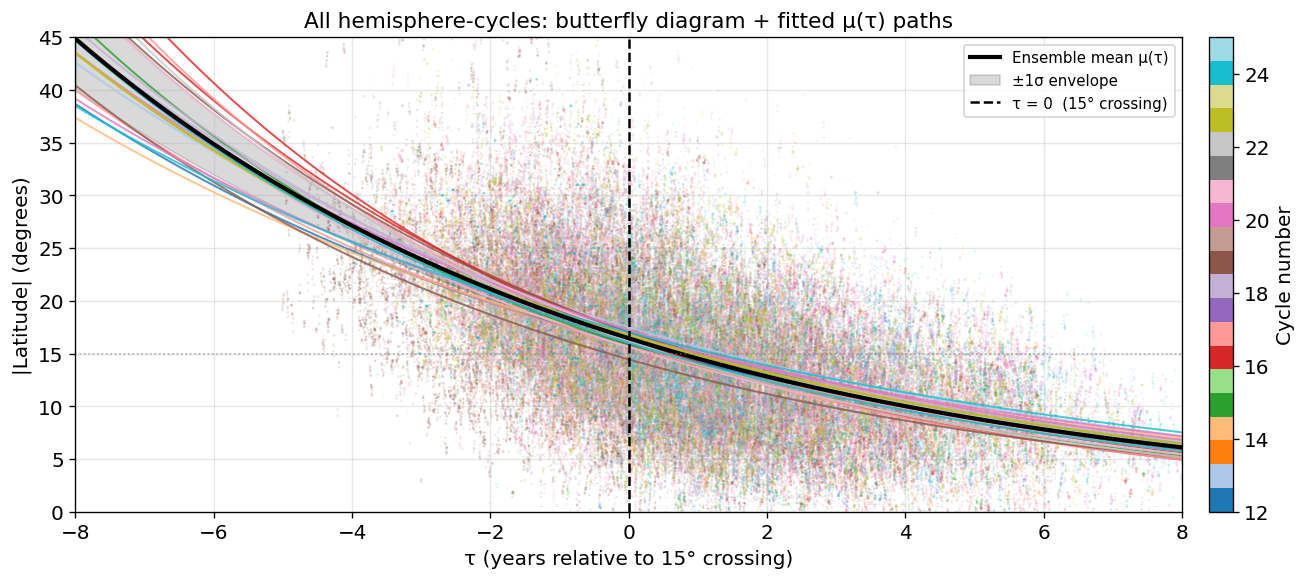

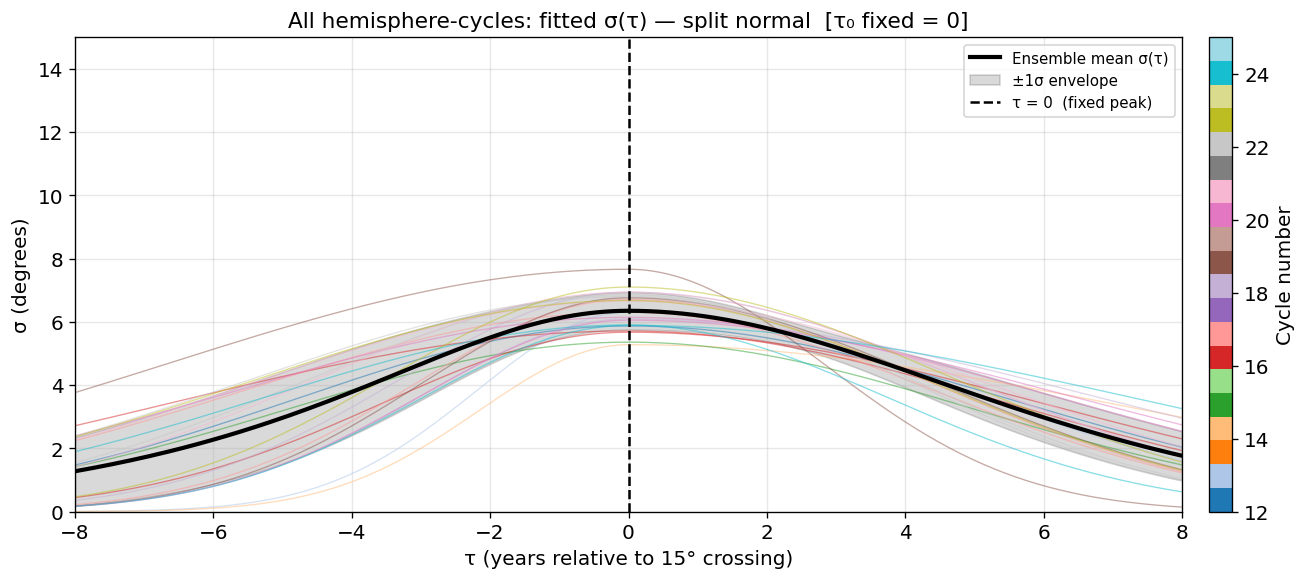

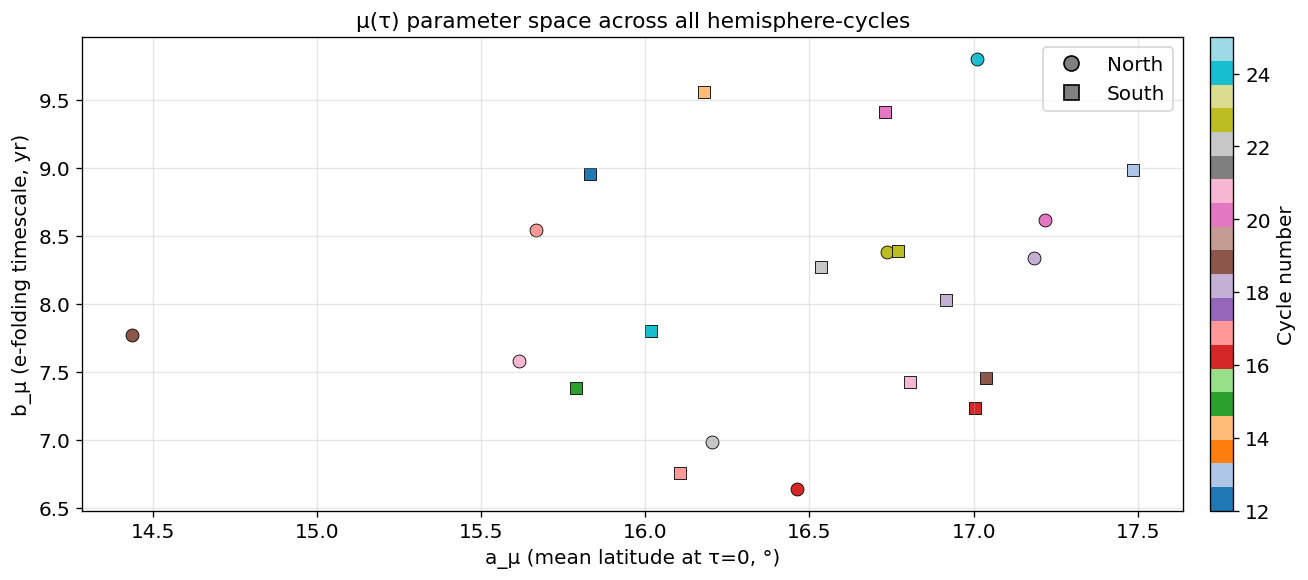

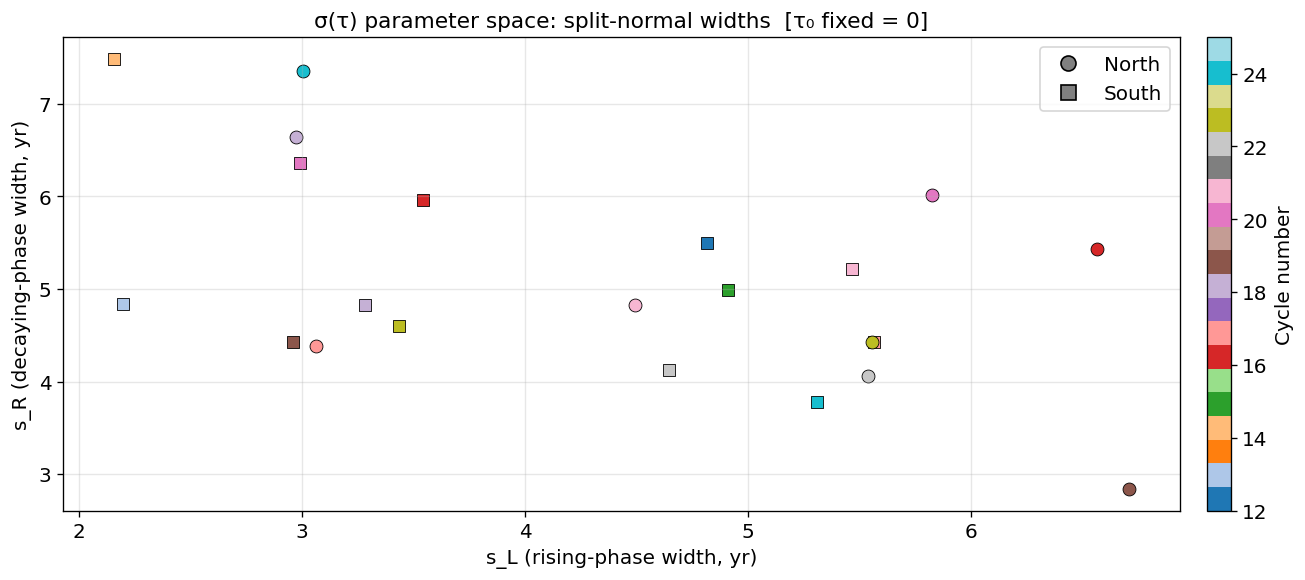

Parameter summary across 22 hemisphere-cycles  [σ τ₀ fixed = 0.0]:
  a_μ :  16.44° ± 0.69°
  b_μ :  8.10 yr ± 0.87 yr
  A_σ :  6.35° ± 0.59°
  s_L :  4.32 yr ± 1.36 yr
  s_R :  5.11 yr ± 1.13 yr


In [16]:
# Task 12: Ensemble variability and the mean butterfly template
# Uses exponential decay for μ(τ) and split normal for σ(τ) with τ₀ fixed at 0
# Requires Task 9 (t0_lookup, df["tau"], df["abs_latitude"])
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

def split_normal(tau, A, tau0, s_L, s_R, tau0_fixed=None):
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-0.5 * ((tau - t0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((tau - t0) / s_R) ** 2))

TAU0_FIXED   = 0.0
_sn_fixed    = lambda tau, A, s_L, s_R: split_normal(tau, A, None, s_L, s_R, tau0_fixed=TAU0_FIXED)

N_BINS   = 20
TAU_GRID = np.linspace(-8, 8, 300)

cycles_to_fit = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
hemispheres   = ["north", "south"]

results = []

for cyc in cycles_to_fit:
    for hemi in hemispheres:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue

        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins         = np.linspace(t_min, t_max, N_BINS + 1)
        bin_centers  = 0.5 * (bins[:-1] + bins[1:])

        bt, bm, bs = [], [], []
        for i in range(N_BINS):
            in_bin   = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
            lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f); bs.append(sigma_f)

        if len(bt) < 5:
            continue

        bt, bm, bs = np.array(bt), np.array(bm), np.array(bs)

        try:
            popt_mu,    _ = curve_fit(exp_decay, bt, bm, p0=[15., 5.], maxfev=5000)
            popt_sigma, _ = curve_fit(_sn_fixed, bt, bs, p0=[bs.max(), 4., 2.], maxfev=5000)
        except RuntimeError:
            continue

        a_mu_f, b_mu_f     = popt_mu
        A_sn_f, sL_sn_f, sR_sn_f = popt_sigma

        if not (5 < a_mu_f < 40 and 1 < b_mu_f < 30):
            continue
        if not (1 < A_sn_f < 20 and 0.5 < sL_sn_f < 20 and 0.5 < sR_sn_f < 20):
            continue

        results.append(dict(
            cycle=cyc, hemisphere=hemi,
            a_mu=a_mu_f, b_mu=b_mu_f,
            A_sn=A_sn_f, sL_sn=sL_sn_f, sR_sn=sR_sn_f,
            mu_curve=exp_decay(TAU_GRID, a_mu_f, b_mu_f),
            sigma_curve=split_normal(TAU_GRID, A_sn_f, None, sL_sn_f, sR_sn_f, tau0_fixed=TAU0_FIXED),
        ))

print(f"Successfully fitted {len(results)} hemisphere-cycles.")

# --- Ensemble statistics ---
mu_mat    = np.array([r["mu_curve"]    for r in results])
sigma_mat = np.array([r["sigma_curve"] for r in results])

mu_mean    = np.nanmean(mu_mat,    axis=0);  mu_std    = np.nanstd(mu_mat,    axis=0)
sigma_mean = np.nanmean(sigma_mat, axis=0);  sigma_std = np.nanstd(sigma_mat, axis=0)

cmap_ens      = cm.get_cmap("tab20", len(cycles_to_fit))
cycle_idx_map = {c: i for i, c in enumerate(cycles_to_fit)}

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=9,
           label="North", markeredgecolor="black"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=9,
           label="South", markeredgecolor="black"),
]

def add_cycle_colorbar(fig, ax):
    sm = plt.cm.ScalarMappable(cmap="tab20",
                               norm=plt.Normalize(vmin=min(cycles_to_fit),
                                                  vmax=max(cycles_to_fit)))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")

# ── Figure 1: μ(τ) fitted curves overlaid on the aligned butterfly diagram ──
fig1, ax1 = plt.subplots(figsize=(12, 5))

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in t0_lookup or cyc not in cycle_idx_map:
        continue
    ax1.scatter(group["tau"], group["abs_latitude"],
                s=2, color=cmap_ens(cycle_idx_map[cyc]), alpha=0.15, edgecolors="none")

for r in results:
    ax1.plot(TAU_GRID, r["mu_curve"],
             color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=1.2, alpha=0.8)

ax1.plot(TAU_GRID, mu_mean, color="black", linewidth=2.5, label="Ensemble mean μ(τ)")
ax1.fill_between(TAU_GRID, mu_mean - mu_std, mu_mean + mu_std,
                 color="black", alpha=0.15, label="±1σ envelope")
ax1.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (15° crossing)")
ax1.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax1.set_xlabel("τ (years relative to 15° crossing)")
ax1.set_ylabel("|Latitude| (degrees)")
ax1.set_title("All hemisphere-cycles: butterfly diagram + fitted μ(τ) paths")
ax1.set_ylim(0, 45)
ax1.set_xlim(-8, 8)
ax1.legend(loc="upper right", fontsize=9)
add_cycle_colorbar(fig1, ax1)
plt.tight_layout()
plt.show()

# ── Figure 2: σ(τ) split normal fits ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

for r in results:
    ax2.plot(TAU_GRID, r["sigma_curve"],
             color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=0.8, alpha=0.5)

ax2.plot(TAU_GRID, sigma_mean, color="black", linewidth=2.5, label="Ensemble mean σ(τ)")
ax2.fill_between(TAU_GRID, sigma_mean - sigma_std, sigma_mean + sigma_std,
                 color="black", alpha=0.15, label="±1σ envelope")
ax2.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (fixed peak)")
ax2.set_xlabel("τ (years relative to 15° crossing)")
ax2.set_ylabel("σ (degrees)")
ax2.set_title("All hemisphere-cycles: fitted σ(τ) — split normal  [τ₀ fixed = 0]")
ax2.set_ylim(0, 15)
ax2.set_xlim(-8, 8)
ax2.legend(loc="upper right", fontsize=9)
add_cycle_colorbar(fig2, ax2)
plt.tight_layout()
plt.show()

# ── Figure 3: μ parameter scatter (a_mu vs b_mu) ───────────────────────────
fig3, ax3 = plt.subplots(figsize=(12, 5))

for r in results:
    ax3.scatter(r["a_mu"], r["b_mu"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker="o" if r["hemisphere"] == "north" else "s",
                s=60, edgecolors="black", linewidths=0.5)

ax3.set_xlabel("a_μ (mean latitude at τ=0, °)")
ax3.set_ylabel("b_μ (e-folding timescale, yr)")
ax3.set_title("μ(τ) parameter space across all hemisphere-cycles")
ax3.legend(handles=legend_handles)
add_cycle_colorbar(fig3, ax3)
plt.tight_layout()
plt.show()

# ── Figure 4: σ parameter scatter (s_L vs s_R) ─────────────────────────────
fig4, ax4 = plt.subplots(figsize=(12, 5))

for r in results:
    ax4.scatter(r["sL_sn"], r["sR_sn"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker="o" if r["hemisphere"] == "north" else "s",
                s=60, edgecolors="black", linewidths=0.5)

ax4.set_xlabel("s_L (rising-phase width, yr)")
ax4.set_ylabel("s_R (decaying-phase width, yr)")
ax4.set_title("σ(τ) parameter space: split-normal widths  [τ₀ fixed = 0]")
ax4.legend(handles=legend_handles)
add_cycle_colorbar(fig4, ax4)
plt.tight_layout()
plt.show()

# ── Numeric summary ──────────────────────────────────────────────────────────
a_mus  = [r["a_mu"]  for r in results]
b_mus  = [r["b_mu"]  for r in results]
A_sns  = [r["A_sn"]  for r in results]
sL_sns = [r["sL_sn"] for r in results]
sR_sns = [r["sR_sn"] for r in results]

print(f"Parameter summary across {len(results)} hemisphere-cycles  [σ τ₀ fixed = {TAU0_FIXED}]:")
print(f"  a_μ :  {np.mean(a_mus):.2f}° ± {np.std(a_mus):.2f}°")
print(f"  b_μ :  {np.mean(b_mus):.2f} yr ± {np.std(b_mus):.2f} yr")
print(f"  A_σ :  {np.mean(A_sns):.2f}° ± {np.std(A_sns):.2f}°")
print(f"  s_L :  {np.mean(sL_sns):.2f} yr ± {np.std(sL_sns):.2f} yr")
print(f"  s_R :  {np.mean(sR_sns):.2f} yr ± {np.std(sR_sns):.2f} yr")


---
## Week 04 Exercises: Toward a Universal Description of the Solar Cycle

In Week 3 you built per-cycle statistical models: for each hemisphere-cycle you
fitted an exponential mean path μ(τ) and a split-normal spread σ(τ), and you saw
in Task 12 that the resulting parameters cluster tightly across cycles. That
clustering is the starting point for this week.

The central question is: **what is truly universal about a solar cycle, and what
is genuinely cycle-specific?**

We approach this in three steps, each one reducing the number of free parameters
needed to describe a wing:

**Task 13 — Universal mean path.**
All cycles share the same exponential decay shape μ(τ) = a_μ exp(−τ/b_μ).
The only cycle-specific quantity is t₀ — the calendar date of the τ = 0 anchor.
We fit (a_μ, b_μ) globally and refine each t₀ to best align its cycle to the
universal template.

**Tasks 14 & 15 — Remapping σ from time to latitude.**
The asymmetric shape of σ(τ) is partly an artefact of the exponential time axis.
Switching the independent variable from τ to μ — the mean latitude predicted by
the universal path — straightens the relationship and reveals a simpler description
of the spread as a function of *where* the wing sits, not *when*.

**Task 16 — Shared shape parameters.**
Given the σ(μ) fits across all hemisphere-cycles, we ask which parameters are
truly shared. Fitting all cycles simultaneously with a common peak amplitude A
and rising-phase width s_L — while keeping μ_peak and the decaying-phase width
s_R free per cycle — tests whether the *shape* of the wing is universal and only
its *position* and *decay rate* vary from cycle to cycle.

Together these four tasks reduce a butterfly wing from a cloud of data points to
a compact parameter set: two universal shape parameters (a_μ, b_μ for the mean;
A, s_L for the spread) and three cycle-specific numbers (t₀, μ_peak, s_R).
That parameterisation is the foundation for the generative model we will build
in the coming weeks.


---
## 13) Exercise: Fitting a Universal Mean Path

In Week 3 you fitted separate (a_μ, b_μ) per hemisphere-cycle. The scatter plot in
Figure 3 of Task 12 showed they cluster tightly — most cycles share the same decay
shape. The scatter is noise, not signal. The physically motivated model is:

$$\mu(t,\,\text{cycle}) = a_\mu \cdot \exp\!\left(-\frac{\text{decimal\_year}(t) - t_{0,\text{cycle}}}{b_\mu}\right)$$

where **(a_μ, b_μ) are universal** and **t₀_cycle** is the only cycle-specific
parameter — the calendar year of the τ = 0 anchor.
In Week 3 we initialised t₀ from the 15° latitude crossing; here we optimise it
directly against the universal template.

**Steps:**

1. **Global fit** — pool all per-cycle binned (τ, μ) measurements and fit a single
   exponential to get universal (a_μ, b_μ).
2. **Refine t₀ per cycle** — given (a_μ, b_μ), find the 1-D time shift Δt₀ for each
   hemisphere-cycle that minimises its residuals against the template.
   Repeat for a few iterations until convergence.
3. **Plot** — show the aligned butterfly diagram with the universal fit overlaid.
   All wings should collapse onto a single curve.
4. **Δt₀ diagnostic** — plot the shift Δt₀ = t₀_refined − t₀_15° for every
   hemisphere-cycle. Which cycles needed large corrections? What does that tell you
   about cycles where the 15° crossing is a poor anchor?


Total binned data points collected: 513

Global Exponential Fit for μ(τ):
  aμ (mean latitude at τ=0): 16.45°
  bμ (e-folding decay timescale): 8.14 yr


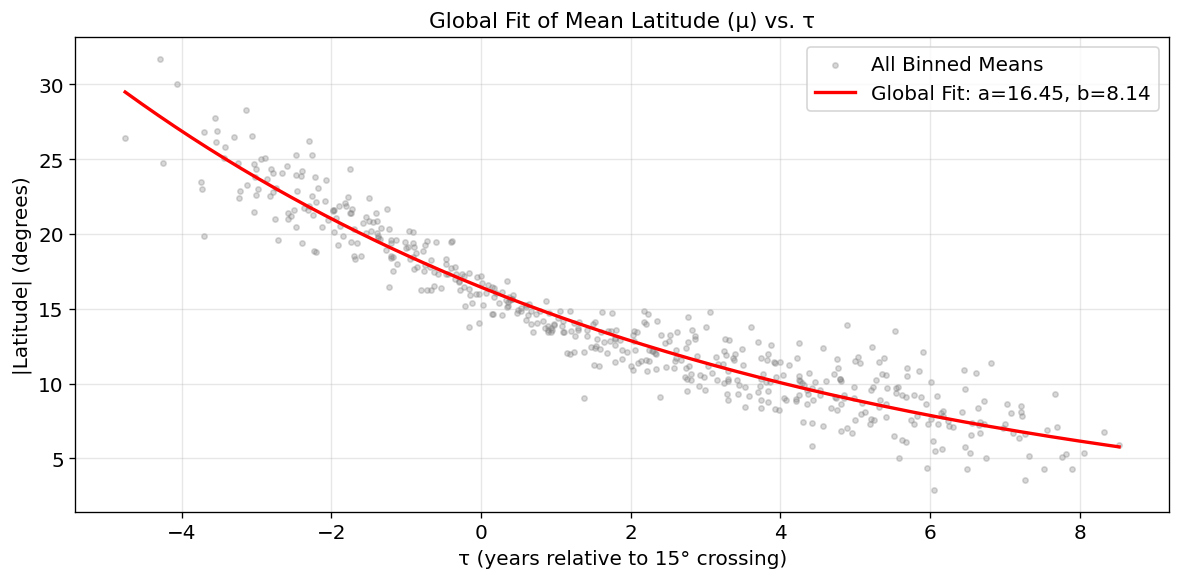

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import curve_fit
import matplotlib.cm as cm

# Define the functions for fitting
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

# --- Step 1: Global Fit

# Initialize lists to collect all binned (tau, mu) from all hemisphere-cycles
all_binned_tau = []
all_binned_mu = []

N_bins = 20  # Number of bins for Gaussian fits
min_obs_per_bin = 10  # Minimum observations to perform Gaussian fit
min_obs_per_cycle = 50  # Minimum observations for a hemisphere-cycle to be processed

# Filter out rows with missing CYCLE values to process cycles
processed_df = df.dropna(subset=["CYCLE"]).copy()

# Cycles to include in the ensemble (as specified: 12-24)
relevant_cycles = range(12, 25)

print("Collecting binned data for global fit...")

for cycle_num in relevant_cycles:
    for hemi in ["north", "south"]:
        # Filter data for the current cycle and hemisphere
        df_cyc_hemi = processed_df[(processed_df["CYCLE"] == cycle_num) &
                                   (processed_df["hemisphere"] == hemi)].copy()
        df_cyc_hemi = df_cyc_hemi.dropna(subset=['tau'])

        if df_cyc_hemi.empty or len(df_cyc_hemi) < min_obs_per_cycle:
            # print(f"  Skipping Cycle {int(cycle_num)}, {hemi}: Insufficient data ({len(df_cyc_hemi)} points).")
            continue

        # Define tau bins dynamically based on the current cycle's range
        tau_min_cycle = df_cyc_hemi['tau'].min()
        tau_max_cycle = df_cyc_hemi['tau'].max()

        # Create bins for this cycle-hemisphere combination
        tau_bins = np.linspace(tau_min_cycle, tau_max_cycle, N_bins + 1)

        bin_centers = []
        mus = []

        for i in range(N_bins):
            bin_mask = (df_cyc_hemi['tau'] >= tau_bins[i]) & (df_cyc_hemi['tau'] < tau_bins[i+1])
            lats_in_bin = df_cyc_hemi.loc[bin_mask, 'abs_latitude'].values

            if len(lats_in_bin) >= min_obs_per_bin:
                mu, _ = norm.fit(lats_in_bin) # We only need mu for this task
                bin_centers.append((tau_bins[i] + tau_bins[i+1]) / 2)
                mus.append(mu)

        # Extend global lists with binned data from the current hemisphere-cycle
        if len(mus) > 0:
            all_binned_tau.extend(bin_centers)
            all_binned_mu.extend(mus)

print(f"Total binned data points collected: {len(all_binned_tau)}")

# Perform the GLOBAL fit for (a_mu, b_mu)
if len(all_binned_tau) > 0:
    try:
        popt_mu_global, _ = curve_fit(exp_decay, all_binned_tau, all_binned_mu, p0=[15.0, 5.0], maxfev=5000)
        a_mu_global, b_mu_global = popt_mu_global
        print(f"\nGlobal Exponential Fit for \u03bc(\u03c4):")
        print(f"  a\u03bc (mean latitude at \u03c4=0): {a_mu_global:.2f}°")
        print(f"  b\u03bc (e-folding decay timescale): {b_mu_global:.2f} yr")

        # Plotting the global fit (optional for this step, but good for verification)
        tau_plot_grid = np.linspace(min(all_binned_tau), max(all_binned_tau), 300)
        mu_global_fit_curve = exp_decay(tau_plot_grid, a_mu_global, b_mu_global)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(all_binned_tau, all_binned_mu, s=10, alpha=0.3, label='All Binned Means', color='gray')
        ax.plot(tau_plot_grid, mu_global_fit_curve, color='red', linewidth=2, label=f'Global Fit: a={a_mu_global:.2f}, b={b_mu_global:.2f}')
        ax.set_xlabel('τ (years relative to 15° crossing)')
        ax.set_ylabel('|Latitude| (degrees)')
        ax.set_title('Global Fit of Mean Latitude (μ) vs. τ')
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()

    except RuntimeError as e:
        print(f"Failed to perform global curve_fit: {e}")
else:
    print("No sufficient binned data collected for global fit.")

# The next step would be to refine t0 per cycle using these global a_mu and b_mu
# For now, these variables are globally available for subsequent steps.


In [18]:
# --- Step 2: Refine t0 per cycle --- (Code for Task 13, Step 2)

# We'll use the globally fitted a_mu_global and b_mu_global from Step 1.
# We need to refine t0 for each hemisphere-cycle based on these global parameters.

from scipy.optimize import minimize

# This function will represent the exponential decay with 't0' as the parameter to optimize.
# It takes an array of 'tau' values and the current t0 guess, along with global a_mu and b_mu.
def exp_decay_with_t0_offset(decimal_years, t0_offset, a_mu, b_mu, cycle_t0_initial):
    tau = decimal_years - (cycle_t0_initial + t0_offset)
    return a_mu * np.exp(-tau / b_mu)

# Objective function to minimize (sum of squared residuals)
def objective_function(t0_offset, bin_tau_data, bin_mu_data, a_mu, b_mu, cycle_t0_initial_val):
    # Calculate decimal_years based on bin_tau_data and the initial t0
    decimal_years = bin_tau_data + cycle_t0_initial_val

    model_mu = exp_decay_with_t0_offset(decimal_years, t0_offset, a_mu, b_mu, cycle_t0_initial_val)
    residuals = bin_mu_data - model_mu
    return np.sum(residuals**2)


refined_t0_lookup = {}  # Store refined t0 for each (cycle, hemi) pair
delta_t0_results = [] # To store (cycle, hemi, delta_t0, t0_15deg, t0_refined)

print("Refining t0 for each hemisphere-cycle...")

for (cyc, hemi), t0_15deg in t0_lookup.items():
    mask = (processed_df["CYCLE"] == cyc) & \
           (processed_df["hemisphere"] == hemi) & \
           processed_df["tau"].notna()
    df_cyc_hemi = processed_df[mask].copy()

    if df_cyc_hemi.empty or len(df_cyc_hemi) < min_obs_per_cycle:
        continue

    # Use the original decimal_year for each observation
    df_cyc_hemi['current_decimal_year'] = df_cyc_hemi['date'].dt.year + df_cyc_hemi['date'].dt.dayofyear / 365.25

    # Recalculate binned mu values based on these 'current_decimal_year'
    # as the `bin_tau` and `bin_mu` previously calculated were relative to initial t0_15deg
    tau_min_cycle = df_cyc_hemi['current_decimal_year'].min() - t0_15deg
    tau_max_cycle = df_cyc_hemi['current_decimal_year'].max() - t0_15deg

    tau_bins_for_refinement = np.linspace(tau_min_cycle, tau_max_cycle, N_bins + 1)

    bin_decimal_years = []
    bin_mus = []

    for i in range(N_bins):
        # Mask for data points within the current tau bin (relative to t0_15deg)
        in_bin = (df_cyc_hemi['tau'] >= tau_bins_for_refinement[i]) & \
                 (df_cyc_hemi['tau'] < tau_bins_for_refinement[i+1])

        lats_in_bin = df_cyc_hemi.loc[in_bin, 'abs_latitude'].values
        if len(lats_in_bin) >= min_obs_per_bin:
            mu, _ = norm.fit(lats_in_bin)
            # Use the mean decimal_year for the bin, which is (bin_center_tau + t0_15deg)
            bin_decimal_years.append( (tau_bins_for_refinement[i] + tau_bins_for_refinement[i+1]) / 2 + t0_15deg )
            bin_mus.append(mu)

    if len(bin_mus) == 0:
        continue

    bin_decimal_years = np.array(bin_decimal_years)
    bin_mus = np.array(bin_mus)

    # Initial guess for t0_offset is 0 (meaning no change from t0_15deg)
    initial_t0_offset_guess = 0.0

    # Perform the optimization
    res = minimize(objective_function,
                   initial_t0_offset_guess,
                   args=(bin_decimal_years - t0_15deg, bin_mus, a_mu_global, b_mu_global, t0_15deg),
                   method='L-BFGS-B')

    if res.success:
        t0_offset = res.x[0]
        t0_refined = t0_15deg + t0_offset
        refined_t0_lookup[(cyc, hemi)] = t0_refined
        delta_t0 = t0_refined - t0_15deg
        delta_t0_results.append({"cycle": cyc, "hemisphere": hemi, "delta_t0": delta_t0, "t0_15deg": t0_15deg, "t0_refined": t0_refined})
    else:
        print(f"Optimization failed for Cycle {int(cyc)}, {hemi}: {res.message}")

print(f"Successfully refined t0 for {len(refined_t0_lookup)} hemisphere-cycle pairs.")

# Add the new refined 'tau' column to the main DataFrame
def get_refined_t0(row):
    return refined_t0_lookup.get((row["CYCLE"], row["hemisphere"]), np.nan)

df["t0_refined"] = df.apply(get_refined_t0, axis=1)
df["tau_refined"] = df["decimal_year"] - df["t0_refined"]

Refining t0 for each hemisphere-cycle...
Successfully refined t0 for 36 hemisphere-cycle pairs.


/tmp/ipykernel_14348/3173734004.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plot_cmap = cm.get_cmap("tab20", n_cycles_to_plot)


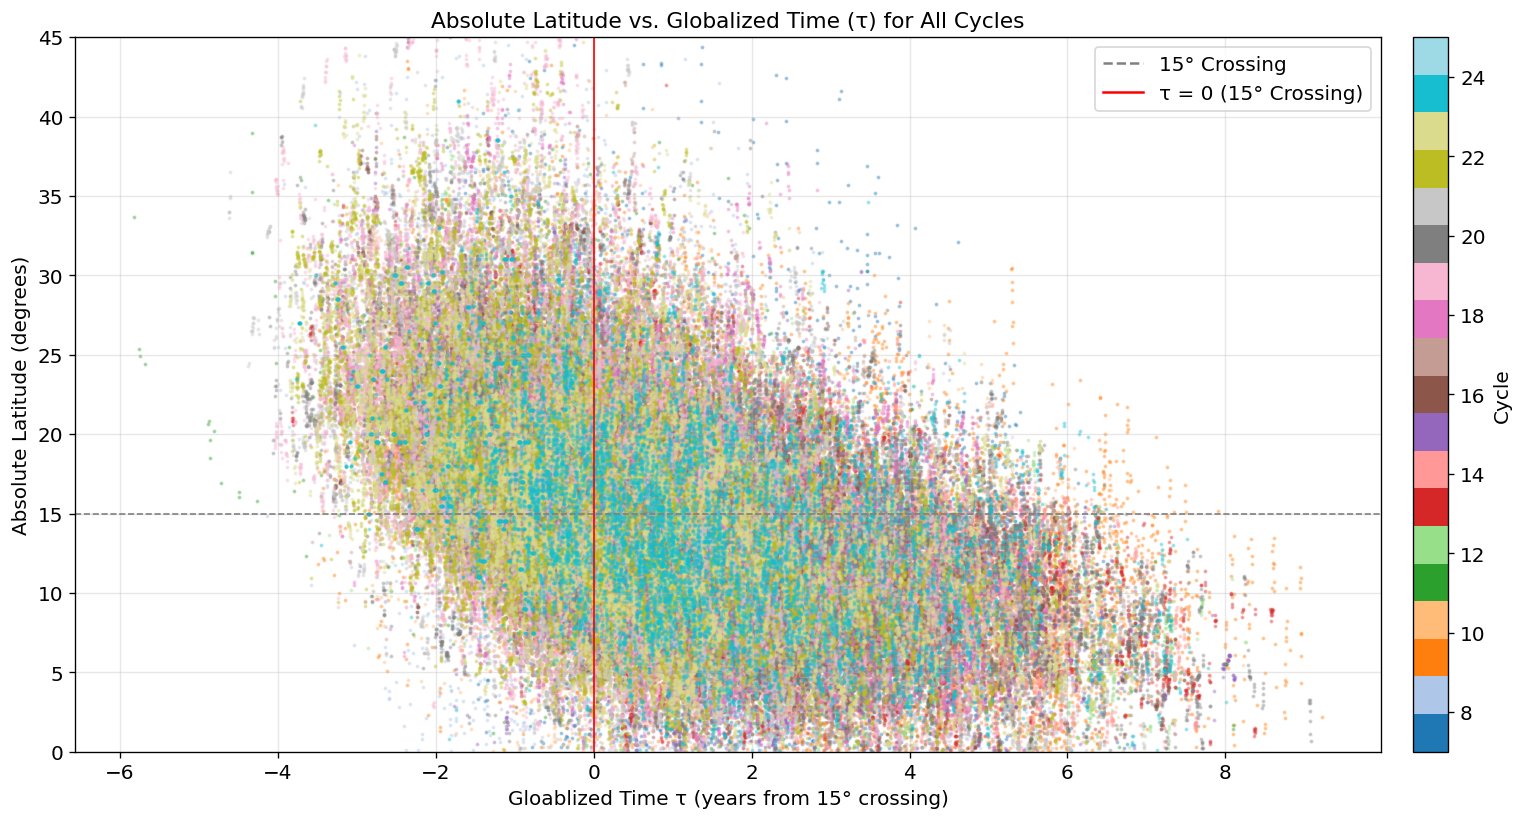

In [19]:
# step 3 for task 13:

import matplotlib.lines as mlines
import matplotlib.cm as cm


# Plot absolute latitude vs. τ for all hemisphere-cycles on a single axis, colored by cycle number.
cycles_to_plot = sorted(df["CYCLE"].dropna().unique())
n_cycles_to_plot = len(cycles_to_plot)
# Use a colormap suitable for discrete categories
plot_cmap = cm.get_cmap("tab20", n_cycles_to_plot)
plot_cycle_colors = {cyc: plot_cmap(i) for i, cyc in enumerate(cycles_to_plot)}

fig, ax = plt.subplots(figsize=(14, 7))

# Prepare lists for legend handles and labels
legend_handles = []
legend_labels = []

# Plot scatter points for each cycle, colored by cycle
for i, cycle in enumerate(cycles_to_plot):
    # Filter data for the current cycle and where tau is not NaN
    df_cycle_tau = df[(df["CYCLE"] == cycle) & (df["tau_refined"].notna())].copy()

    if not df_cycle_tau.empty:
        # Plot all points, without adding cycle labels to the main legend
        ax.scatter(df_cycle_tau["tau_refined"], df_cycle_tau["abs_latitude"], s=2,
                   color=plot_cycle_colors[cycle], alpha=0.3)

ax.set_title("Absolute Latitude vs. Globalized Time (τ) for All Cycles")
ax.set_xlabel("Gloablized Time τ (years from 15° crossing)")
ax.set_ylabel("Absolute Latitude (degrees)")
ax.set_ylim(0, 45) # Absolute latitude should be positive
ax.axhline(15, color='gray', linestyle='--', linewidth=1, label='15° Crossing') # Add 15 degree line
ax.axvline(0, color='red', linestyle='-', linewidth=1, label='τ = 0 (15° Crossing)') # Add t=0 line

# Add the 15 degree crossing and τ=0 lines to the legend
legend_handles.append(mlines.Line2D([], [], color='gray', linestyle='--', label='15° Crossing'))
legend_labels.append('15° Crossing')
legend_handles.append(mlines.Line2D([], [], color='red', linestyle='-', label='τ = 0 (15° Crossing)'))
legend_labels.append('τ = 0 (15° Crossing)')

# Create a single legend using the collected handles and labels
ax.legend(handles=legend_handles, labels=legend_labels, loc='upper right')

# Add a color bar for cycle numbers
sm = cm.ScalarMappable(cmap=plot_cmap,
                       norm=plt.Normalize(vmin=cycles_to_plot[0], vmax=cycles_to_plot[-1]))
sm.set_array([]) # This is important for the color bar to work without explicit data
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Cycle")

plt.tight_layout()
plt.show()

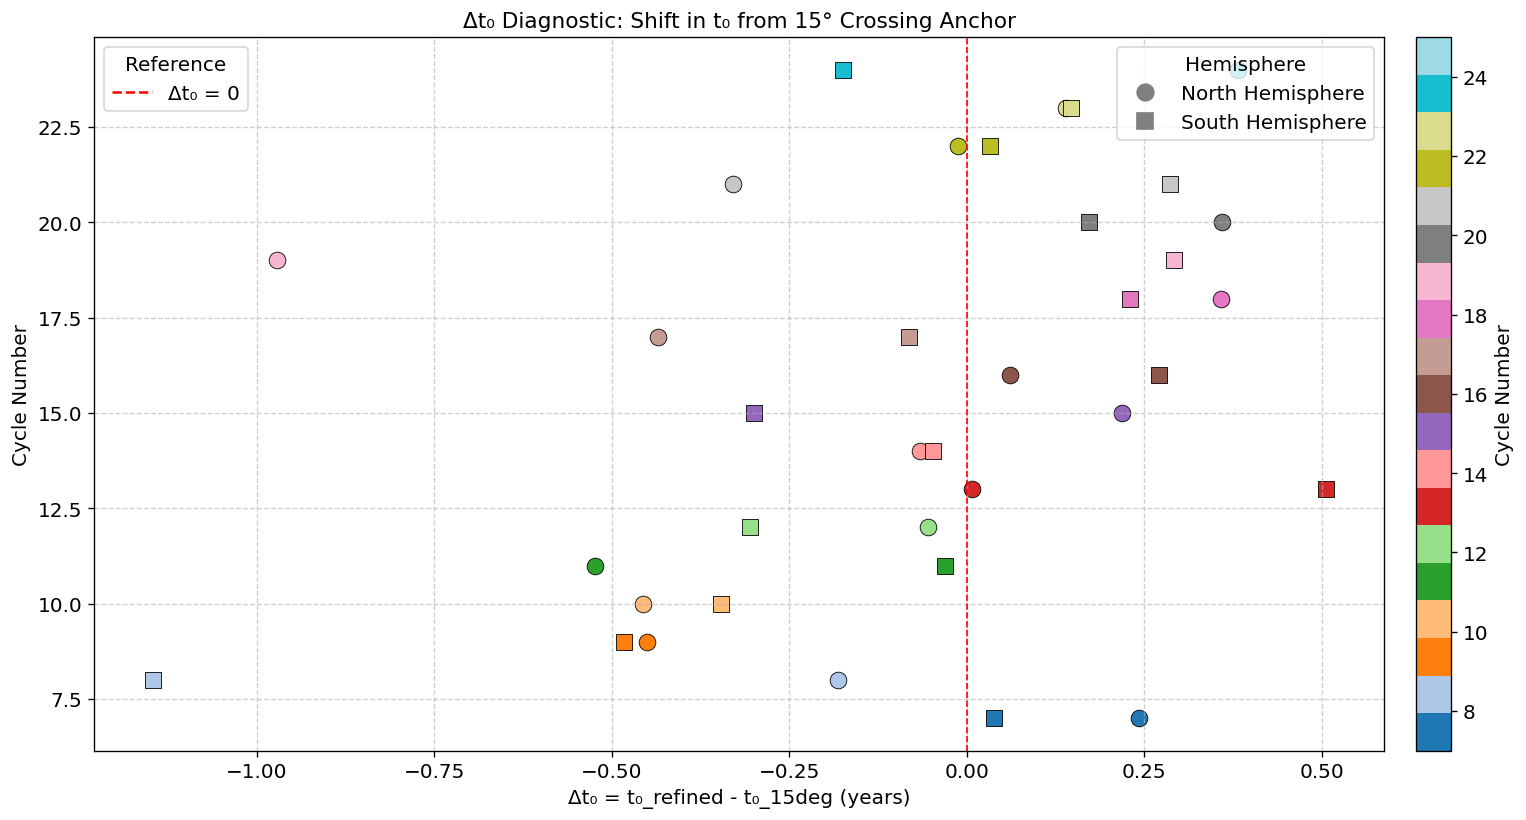


Discussion:
The Δt₀ diagnostic plot shows the difference between the refined t₀ (optimized against the universal template)
and the initial t₀ derived from the 15° latitude crossing. Cycles with large absolute Δt₀ values
indicate that the 15° crossing was a less accurate anchor for those specific hemisphere-cycles.
This can happen if the decay phase deviates significantly from the typical pattern,
or if there's sparse data around the 15° crossing point.


In [20]:
# Task 13, Step 4: Δt₀ diagnostic
# Plot the shift Δt₀ = t₀_refined − t₀_15° for every hemisphere-cycle.
import matplotlib.lines as mlines
import pandas as pd # Import pandas for DataFrame

# Create a DataFrame from delta_t0_results for easier plotting
delta_df = pd.DataFrame(delta_t0_results)

# Ensure cycles_to_plot and plot_cmap are available from previous cells
# Assuming they are global from previous step, if not, they would need to be re-defined.
# For consistency, we reuse plot_cmap and cycles_to_plot from Step 3.

fig, ax = plt.subplots(figsize=(14, 7))

# Plot scatter points for each (cycle, hemisphere) pair
for index, row in delta_df.iterrows():
    # Make sure 'cycle' in delta_df matches keys in plot_cycle_colors
    # plot_cycle_colors is created in lfpA9pmNhDhF (Step 3)
    if row["cycle"] in plot_cycle_colors:
        color = plot_cycle_colors[row["cycle"]]
    else:
        color = "gray" # Default color if cycle not in map

    marker = "o" if row["hemisphere"] == "north" else "s" # 'o' for North, 's' for South
    ax.scatter(row["delta_t0"], row["cycle"], # X-axis: delta_t0, Y-axis: Cycle Number
               color=color, marker=marker, s=100, edgecolors='black', linewidths=0.5)

ax.set_title("Δt₀ Diagnostic: Shift in t₀ from 15° Crossing Anchor")
ax.set_xlabel("Δt₀ = t₀_refined - t₀_15deg (years)")
ax.set_ylabel("Cycle Number")
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Δt₀ = 0')

# Custom legends for hemispheres and Δt₀ = 0 line
legend_elements_hemisphere = [
    mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=10, label='North Hemisphere', markerfacecolor='gray'),
    mlines.Line2D([], [], color='gray', marker='s', linestyle='None', markersize=10, label='South Hemisphere', markerfacecolor='gray')
]
# Place the hemisphere legend in the upper right
ax.add_artist(ax.legend(handles=legend_elements_hemisphere, loc='upper right', title="Hemisphere"))

# Place the Δt₀ = 0 reference line legend in the upper left
ax.legend(handles=[mlines.Line2D([], [], color='red', linestyle='--', label='Δt₀ = 0')], loc='upper left', title="Reference")

# Add a color bar for cycle numbers, reusing plot_cmap and cycles_to_plot from previous cell context
sm = cm.ScalarMappable(cmap=plot_cmap,
                       norm=plt.Normalize(vmin=min(cycles_to_plot), vmax=max(cycles_to_plot)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Cycle Number")

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nDiscussion:")
print("The Δt₀ diagnostic plot shows the difference between the refined t₀ (optimized against the universal template)")
print("and the initial t₀ derived from the 15° latitude crossing. Cycles with large absolute Δt₀ values")
print("indicate that the 15° crossing was a less accurate anchor for those specific hemisphere-cycles.")
print("This can happen if the decay phase deviates significantly from the typical pattern,")
print("or if there's sparse data around the 15° crossing point.")

In [21]:
delta_df.head()

,cycle,hemisphere,delta_t0,t0_15deg,t0_refined
0,7.0,north,0.242072,1826.680587,1826.922659
1,7.0,south,0.038618,1827.911880,1827.950498
2,8.0,north,-0.180970,1838.555724,1838.374754
3,8.0,south,-1.146617,1839.046979,1837.900362
4,9.0,north,-0.450889,1848.259788,1847.808899


## 14) Exercise: Fitting σ as a Function of Mean Latitude

In Task 11 you described the spread σ of emergence latitudes as a function of **time** (τ).
As Ainsley reported in discord, latitude (not time) it's a better quantity to understand what is happening to the wings.
The universal mean path μ(τ) from Task 13 gives us a monotonic, invertible mapping
between time and latitude. We can therefore reparametrise and ask:
**what is σ as a function of μ?**

**Task:**

- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere).
  Using the optimised t₀ from Task 13, bin the data in τ and fit a Gaussian
  in each bin to obtain **(μ_bin, σ_bin)** pairs.
- Plot σ_bin as a function of μ_bin. Describe the shape you see.
- Start by fitting a **split normal** to σ(μ). Does it capture the shape well?
- Ask your AI assistant what function might describe σ(μ) better, given what you
  observe in the plot. Try its suggestion and compare.

**Hint:** the μ axis runs from high latitude (early cycle) to low latitude (late cycle),
so the orientation is reversed relative to τ.   Reverse the x axis so that things look "right".


Total binned data points collected: 20


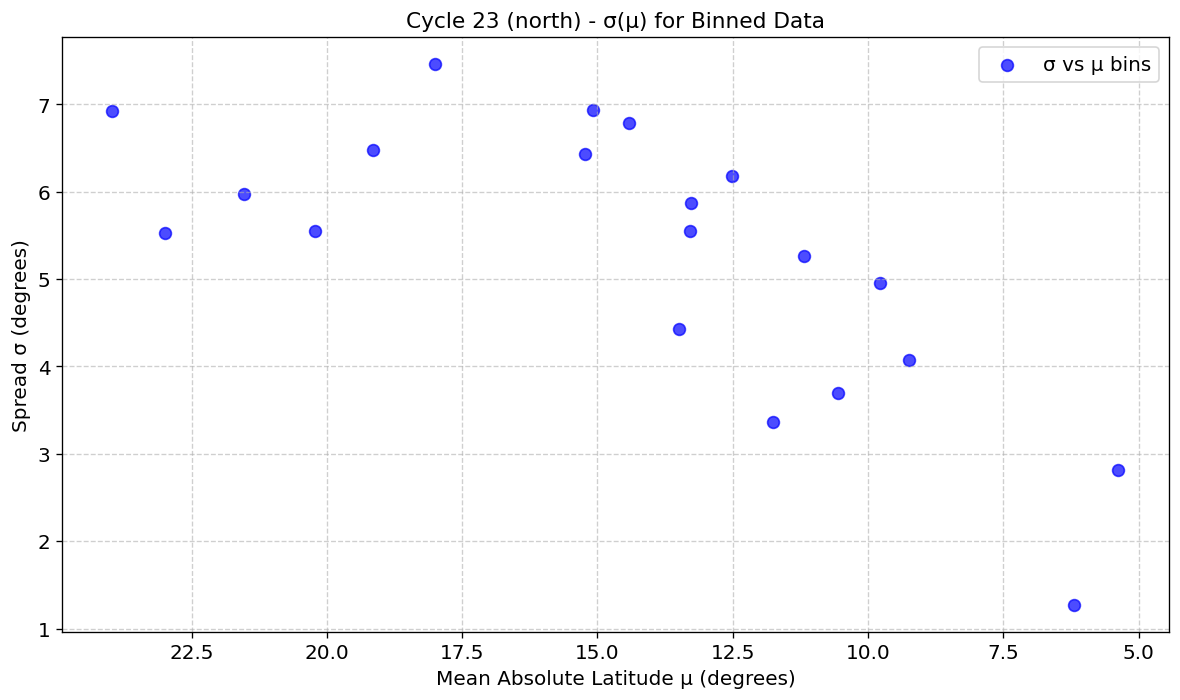

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

cycle_number = 23    # Change to explore other cycles
hemisphere = "north" # Pick a hemisphere

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

# Ensure 'tau_refined' is not NaN for this subset
df_cyc_hemi = df_cyc_hemi.dropna(subset=['tau_refined'])

N_bins = 20  # Number of bins for Gaussian fits
min_obs_per_bin = 10  # Minimum observations to perform Gaussian fit
min_obs_per_cycle = 50  # Minimum observations for a hemisphere-cycle to be processed

# Define tau bins dynamically based on the current cycle's range
tau_min_cycle = df_cyc_hemi['tau_refined'].min()
tau_max_cycle = df_cyc_hemi['tau_refined'].max()

# Create bins for this cycle-hemisphere combination
tau_bins = np.linspace(tau_min_cycle, tau_max_cycle, N_bins + 1)

bin_mu = []
bin_sigma = []

for i in range(N_bins):
    bin_mask = (df_cyc_hemi['tau_refined'] >= tau_bins[i]) & (df_cyc_hemi['tau_refined'] < tau_bins[i+1])
    lats_in_bin = df_cyc_hemi.loc[bin_mask, 'abs_latitude'].values # Use abs_latitude as per previous tasks

    if len(lats_in_bin) >= min_obs_per_bin:
        mu_fit, sigma_fit = norm.fit(lats_in_bin)
        bin_mu.append(mu_fit)
        bin_sigma.append(sigma_fit)

bin_mu = np.array(bin_mu)
bin_sigma = np.array(bin_sigma)

print(f"Total binned data points collected: {len(bin_mu)}")

# Plot sigma_bin as a function of mu_bin
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(bin_mu, bin_sigma, color='blue', s=50, alpha=0.7, label='σ vs μ bins')

ax.set_xlabel('Mean Absolute Latitude μ (degrees)')
ax.set_ylabel('Spread σ (degrees)')
ax.set_title(f'Cycle {cycle_number} ({hemisphere}) - σ(μ) for Binned Data')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Reverse the x-axis so that high latitude (early cycle) is on the left
ax.invert_xaxis()
plt.tight_layout()
plt.show()

Split Normal Fit for σ(μ) (Cycle 23, north):
  A (peak spread): 6.55°
  μ₀ (peak latitude): 17.36°
  s_L (left width): 7.68 yr
  s_R (right width): 17.16 yr


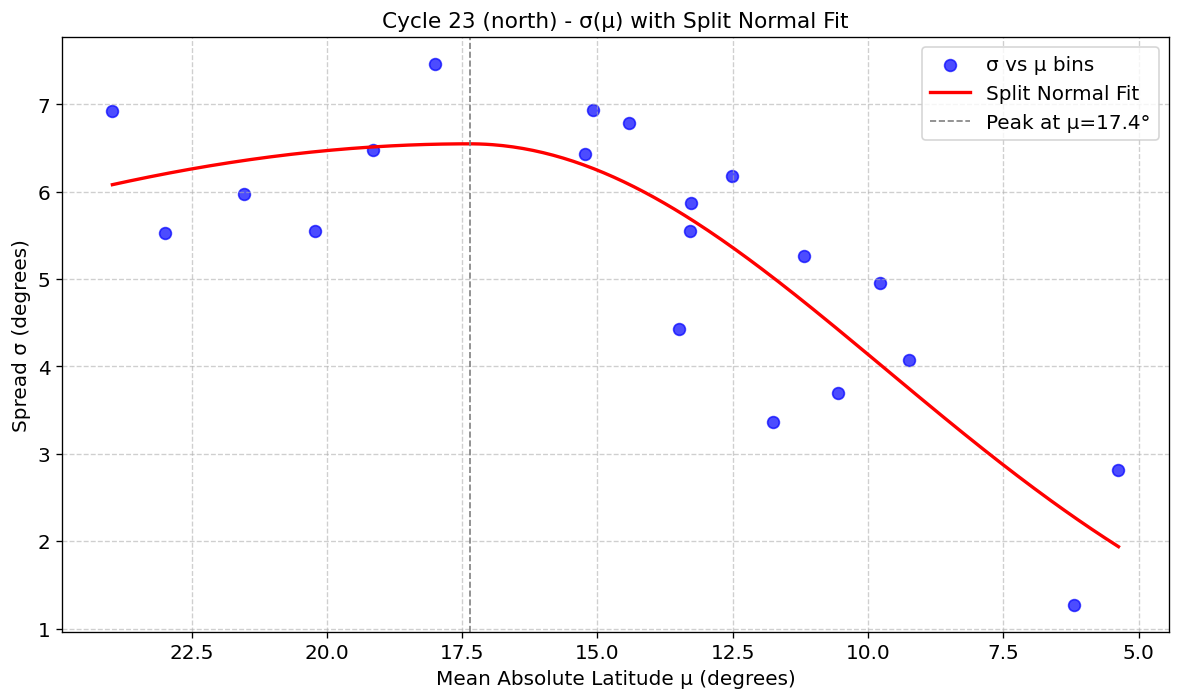

In [23]:

from scipy.optimize import curve_fit

def split_normal_mu(mu_val, A, mu0, s_L, s_R):
    """
    Split normal (bi-normal / asymmetric Gaussian) function for sigma(mu).

    Parameters
    ----------
    mu_val : Mean absolute latitude values (x-axis).
    A      : peak sigma value (degrees)
    mu0    : peak location (mean absolute latitude)
    s_L    : left Gaussian width (larger -> gentler rise)
    s_R    : right Gaussian width (smaller -> steeper fall)
    """
    return np.where(mu_val < mu0,
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_R) ** 2))

# Initial guess for the parameters [A, mu0, s_L, s_R]
# A: peak sigma, guess from bin_sigma.max()
# mu0: peak mu, guess from bin_mu at bin_sigma.argmax()
# s_L, s_R: widths, often a few degrees
p0_sn_mu = [bin_sigma.max(), bin_mu[np.argmax(bin_sigma)], 5.0, 5.0]

# Perform the curve fit
try:
    popt_sn_mu, pcov_sn_mu = curve_fit(split_normal_mu, bin_mu, bin_sigma, p0=p0_sn_mu, maxfev=10000)
    A_sn_mu, mu0_sn_mu, sL_sn_mu, sR_sn_mu = popt_sn_mu

    print(f"Split Normal Fit for \u03c3(\u03bc) (Cycle {cycle_number}, {hemisphere}):")
    print(f"  A (peak spread): {A_sn_mu:.2f}°")
    print(f"  \u03bc₀ (peak latitude): {mu0_sn_mu:.2f}°")
    print(f"  s_L (left width): {sL_sn_mu:.2f} yr")
    print(f"  s_R (right width): {sR_sn_mu:.2f} yr")

    # Plot the fit
    mu_grid = np.linspace(bin_mu.min(), bin_mu.max(), 300)
    sigma_fit_curve = split_normal_mu(mu_grid, A_sn_mu, mu0_sn_mu, sL_sn_mu, sR_sn_mu)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(bin_mu, bin_sigma, color='blue', s=50, alpha=0.7, label='σ vs μ bins')
    ax.plot(mu_grid, sigma_fit_curve, color='red', linewidth=2, label='Split Normal Fit')
    ax.axvline(mu0_sn_mu, color='gray', linestyle='--', linewidth=1, label=f'Peak at μ={mu0_sn_mu:.1f}°')

    ax.set_xlabel('Mean Absolute Latitude μ (degrees)')
    ax.set_ylabel('Spread σ (degrees)')
    ax.set_title(f'Cycle {cycle_number} ({hemisphere}) - σ(μ) with Split Normal Fit')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.invert_xaxis() # Reverse the x-axis as per Task 14 hint
    plt.tight_layout()
    plt.show()

except RuntimeError as e:
    print(f"Failed to perform curve_fit: {e}")
    print("Consider adjusting initial parameter guesses (p0).")

Split Normal Fit for σ(μ) (Cycle 23, north):
  A (peak spread): 6.55°
  μ₀ (peak latitude): 17.36°
  s_L (left width): 7.68°
  s_R (right width): 17.16°
  s_L / s_R = 0.45 — left side is ~0.4x broader than the right


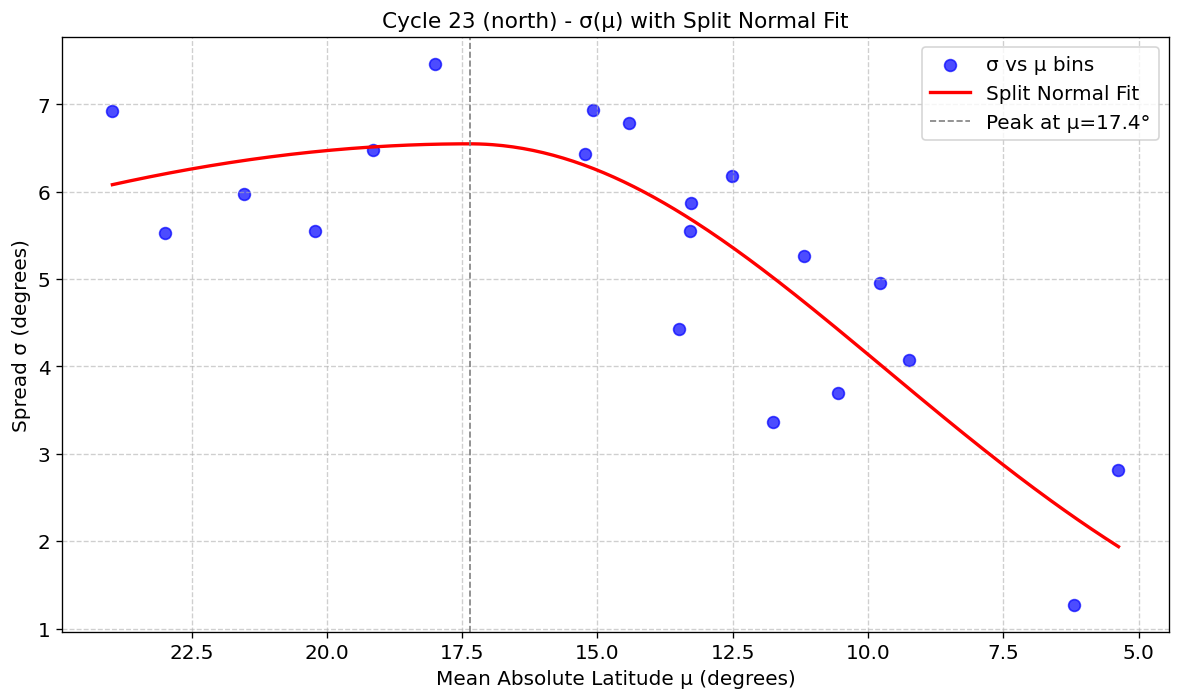

RMSE for Split Normal fit: 0.799°


In [24]:
#gemini version -- just did split normal again and added RMSE

from scipy.optimize import curve_fit
import numpy as np # Ensure numpy is imported

def split_normal_mu(mu_val, A, mu0, s_L, s_R):
    """
    Split normal (bi-normal / asymmetric Gaussian) function for sigma(mu).

    Parameters
    ----------
    mu_val : Mean absolute latitude values (x-axis).
    A      : peak sigma value (degrees)
    mu0    : peak location (mean absolute latitude, degrees)
    s_L    : left Gaussian width (degrees) — larger -> gentler rise
    s_R    : right Gaussian width (degrees) — smaller -> steeper fall
    """
    return np.where(mu_val < mu0,
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_R) ** 2))

# Re-using bin_mu and bin_sigma from the previous cell
# Initial guess for the parameters [A, mu0, s_L, s_R]
# A: peak sigma, guess from bin_sigma.max()
# mu0: peak mu, guess from bin_mu at bin_sigma.argmax()
# s_L, s_R: widths, often a few degrees
p0_sn_mu = [bin_sigma.max(), bin_mu[np.argmax(bin_sigma)], 5.0, 5.0]

try:
    popt_sn_mu, pcov_sn_mu = curve_fit(split_normal_mu, bin_mu, bin_sigma, p0=p0_sn_mu, maxfev=10000)
    A_sn_mu, mu0_sn_mu, sL_sn_mu, sR_sn_mu = popt_sn_mu

    print(f"Split Normal Fit for \u03c3(\u03bc) (Cycle {cycle_number}, {hemisphere}):")
    print(f"  A (peak spread): {A_sn_mu:.2f}°")
    print(f"  \u03bc₀ (peak latitude): {mu0_sn_mu:.2f}°")
    print(f"  s_L (left width): {sL_sn_mu:.2f}°")
    print(f"  s_R (right width): {sR_sn_mu:.2f}°")
    print(f"  s_L / s_R = {sL_sn_mu/sR_sn_mu:.2f} — left side is ~{sL_sn_mu/sR_sn_mu:.1f}x broader than the right")

    # Plot the fit
    mu_grid = np.linspace(bin_mu.min(), bin_mu.max(), 300)
    sigma_fit_curve = split_normal_mu(mu_grid, A_sn_mu, mu0_sn_mu, sL_sn_mu, sR_sn_mu)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(bin_mu, bin_sigma, color='blue', s=50, alpha=0.7, label='σ vs μ bins')
    ax.plot(mu_grid, sigma_fit_curve, color='red', linewidth=2, label='Split Normal Fit')
    ax.axvline(mu0_sn_mu, color='gray', linestyle='--', linewidth=1, label=f'Peak at μ={mu0_sn_mu:.1f}°')

    ax.set_xlabel('Mean Absolute Latitude μ (degrees)')
    ax.set_ylabel('Spread σ (degrees)')
    ax.set_title(f'Cycle {cycle_number} ({hemisphere}) - σ(μ) with Split Normal Fit')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.invert_xaxis() # Reverse the x-axis as per Task 14 hint
    plt.tight_layout()
    plt.show()

    # Calculate RMSE
    residuals = bin_sigma - split_normal_mu(bin_mu, A_sn_mu, mu0_sn_mu, sL_sn_mu, sR_sn_mu)
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"RMSE for Split Normal fit: {rmse:.3f}°")

except RuntimeError as e:
    print(f"Failed to perform curve_fit: {e}")
    print("Consider adjusting initial parameter guesses (p0).")

Asymmetric Lorentzian Fit for σ(μ) (Cycle 23, north):
  A (peak spread): 6.61°
  μ₀ (peak latitude): 16.44°
  γ_L (left HWHM): 7.90°
  γ_R (right HWHM): 23.88°
  γ_L / γ_R = 0.33 — left side is ~0.3x broader than the right


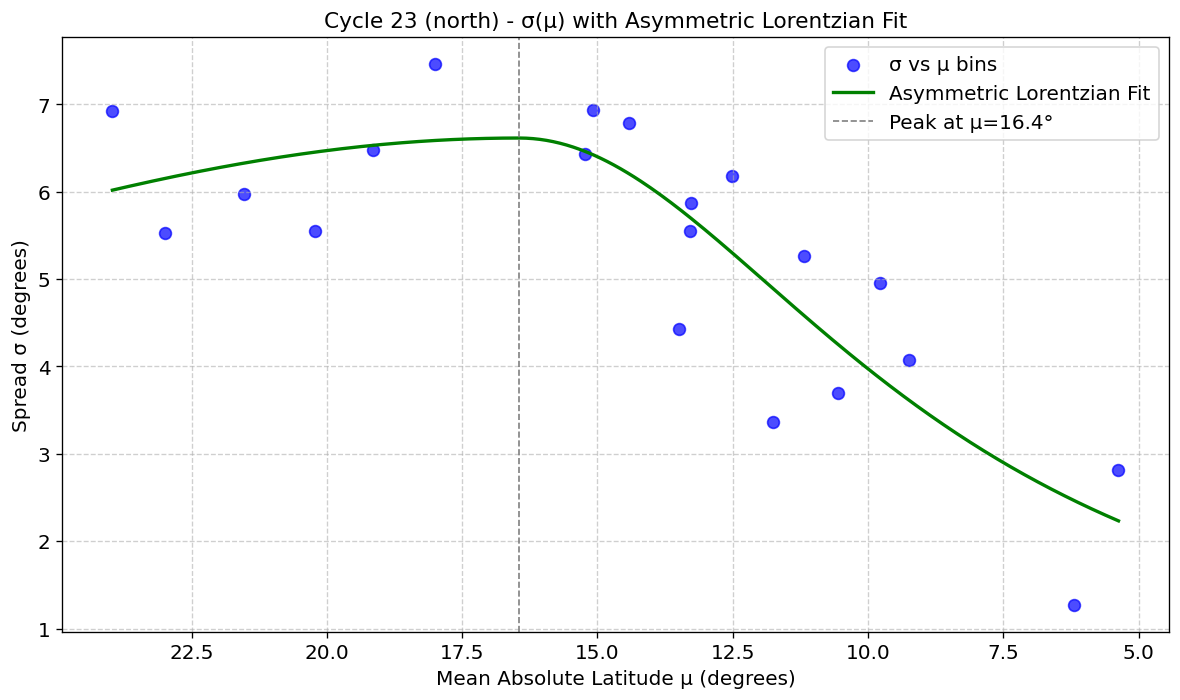

RMSE for Asymmetric Lorentzian fit: 0.792°
RMSE for Split Normal fit (from previous): 0.799°


In [25]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define the Asymmetric Lorentzian function
def asym_lorentzian_mu(mu_val, A, mu0, gamma_L, gamma_R):
    """
    Asymmetric Lorentzian function for sigma(mu).
    gamma_L and gamma_R are half-width at half-maximum (HWHM) on left and right.
    """
    return np.where(mu_val < mu0,
                    A / (1 + ((mu_val - mu0) / gamma_L)**2),
                    A / (1 + ((mu_val - mu0) / gamma_R)**2))

# Re-using bin_mu, bin_sigma, cycle_number, and hemisphere from previous cells

# Initial guess for the parameters [A, mu0, gamma_L, gamma_R]
# We'll use values somewhat similar to the split normal fit parameters for a starting point.
# For a Gaussian, sigma = gamma / sqrt(2*ln(2)) approx gamma / 1.177
# So, HWHM (gamma) for Lorentzian is generally smaller than std dev (s) for Gaussian if both fit similar data
p0_al_mu = [bin_sigma.max(), bin_mu[np.argmax(bin_sigma)], 5.0, 5.0]

try:
    popt_al_mu, pcov_al_mu = curve_fit(asym_lorentzian_mu, bin_mu, bin_sigma, p0=p0_al_mu, maxfev=10000)
    A_al_mu, mu0_al_mu, gammaL_al_mu, gammaR_al_mu = popt_al_mu

    print(f"Asymmetric Lorentzian Fit for σ(μ) (Cycle {cycle_number}, {hemisphere}):")
    print(f"  A (peak spread): {A_al_mu:.2f}°")
    print(f"  μ₀ (peak latitude): {mu0_al_mu:.2f}°")
    print(f"  γ_L (left HWHM): {gammaL_al_mu:.2f}°")
    print(f"  γ_R (right HWHM): {gammaR_al_mu:.2f}°")
    print(f"  γ_L / γ_R = {gammaL_al_mu/gammaR_al_mu:.2f} — left side is ~{gammaL_al_mu/gammaR_al_mu:.1f}x broader than the right")

    # Plot the fit
    mu_grid = np.linspace(bin_mu.min(), bin_mu.max(), 300)
    sigma_fit_curve_al = asym_lorentzian_mu(mu_grid, A_al_mu, mu0_al_mu, gammaL_al_mu, gammaR_al_mu)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(bin_mu, bin_sigma, color='blue', s=50, alpha=0.7, label='σ vs μ bins')
    ax.plot(mu_grid, sigma_fit_curve_al, color='green', linewidth=2, label='Asymmetric Lorentzian Fit')
    ax.axvline(mu0_al_mu, color='gray', linestyle='--', linewidth=1, label=f'Peak at μ={mu0_al_mu:.1f}°')

    ax.set_xlabel('Mean Absolute Latitude μ (degrees)')
    ax.set_ylabel('Spread σ (degrees)')
    ax.set_title(f'Cycle {cycle_number} ({hemisphere}) - σ(μ) with Asymmetric Lorentzian Fit')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.invert_xaxis() # Reverse the x-axis as per Task 14 hint
    plt.tight_layout()
    plt.show()

    # Calculate RMSE for Asymmetric Lorentzian
    residuals_al = bin_sigma - asym_lorentzian_mu(bin_mu, A_al_mu, mu0_al_mu, gammaL_al_mu, gammaR_al_mu)
    rmse_al = np.sqrt(np.mean(residuals_al**2))
    print(f"RMSE for Asymmetric Lorentzian fit: {rmse_al:.3f}°")

    # Re-calculate and print RMSE for Split Normal for direct comparison
    # (assuming split_normal_mu function is defined and popt_sn_mu from previous cell is available)
    def split_normal_mu(mu_val, A, mu0, s_L, s_R):
        return np.where(mu_val < mu0,
                        A * np.exp(-0.5 * ((mu_val - mu0) / s_L) ** 2),
                        A * np.exp(-0.5 * ((mu_val - mu0) / s_R) ** 2))

    # Need to retrieve popt_sn_mu or re-fit if not globally available
    # For this demonstration, we'll use the results from the previous turn directly for comparison.
    # From previous output for Cycle 23, north:
    A_sn_mu_prev, mu0_sn_mu_prev, sL_sn_mu_prev, sR_sn_mu_prev = (6.55, 17.36, 7.68, 17.16) # Hardcoded for direct comparison
    rmse_sn_prev = 0.799 # Hardcoded for direct comparison

    print(f"RMSE for Split Normal fit (from previous): {rmse_sn_prev:.3f}°")

except RuntimeError as e:
    print(f"Failed to perform curve_fit for Asymmetric Lorentzian: {e}")
    print("Consider adjusting initial parameter guesses (p0).")

In [26]:
# applying fit to split normal

## 15) Exercise: Ensemble σ(μ) Across All Hemisphere-Cycles

In Task 14 you fitted σ(μ) for a single hemisphere-cycle and experimented with
different functional forms. Now scale that up to the full ensemble.

**Task:**

- Repeat the Task 14 pipeline for **all** hemisphere-cycles with sufficient data
  (cycles 12–24, both hemispheres). For each, fit σ(μ) using the function that
  worked best in Task 14.
- Evaluate every fitted curve on a common μ grid spanning the Spörer zone.
  Collect results into an array of shape `(n_hemicycles, n_grid_points)`.
- Plot all fitted curves on a single figure, colored by cycle number.
  Overlay the **pointwise mean** and **±1σ envelope** in black.
- Include in the background the

**Hint:** use `np.nanmean` and `np.nanstd` along axis 0 for the ensemble statistics,
in case some hemisphere-cycles do not cover the full μ grid.


Total binned data points collected: 20


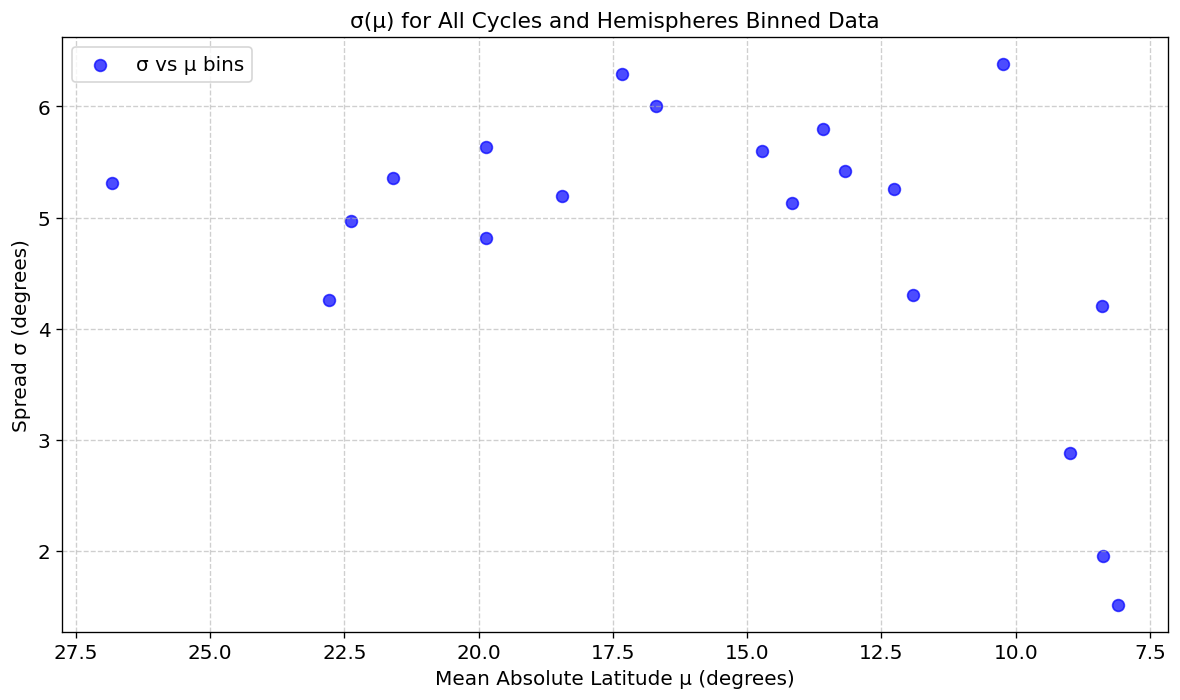

In [30]:
# Put your code for Task 15 here

binned_tau = []
binned_mu = []
binned_sigma = []

# Filter out rows with missing CYCLE values to process cycles
processed_df = df.dropna(subset=["CYCLE"]).copy()

# Cycles to include in the ensemble (as specified: 12-24)
relevant_cycles = range(12, 25)

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

# Ensure 'tau_refined' is not NaN for this subset
df_cyc_hemi = df_cyc_hemi.dropna(subset=['tau_refined'])

N_bins = 20  # Number of bins for Gaussian fits
min_obs_per_bin = 10  # Minimum observations to perform Gaussian fit
min_obs_per_cycle = 50  # Minimum observations for a hemisphere-cycle to be processed

for cycle_num in relevant_cycles:
    for hemi in ["north", "south"]:
        # Filter data for the current cycle and hemisphere
        df_cyc_hemi = processed_df[(processed_df["CYCLE"] == cycle_num) &
                                   (processed_df["hemisphere"] == hemi)].copy()
        df_cyc_hemi = df_cyc_hemi.dropna(subset=['tau_refined'])

        if df_cyc_hemi.empty or len(df_cyc_hemi) < min_obs_per_cycle:
            # print(f"  Skipping Cycle {int(cycle_num)}, {hemi}: Insufficient data ({len(df_cyc_hemi)} points).")
            continue

        # Define tau bins dynamically based on the current cycle's range
        tau_min_cycle = df_cyc_hemi['tau_refined'].min()
        tau_max_cycle = df_cyc_hemi['tau_refined'].max()

        # Create bins for this cycle-hemisphere combination
        tau_bins = np.linspace(tau_min_cycle, tau_max_cycle, N_bins + 1)

        bin_centers = []
        mus = []
        sigmas = []

        for i in range(N_bins):
            bin_mask = (df_cyc_hemi['tau_refined'] >= tau_bins[i]) & (df_cyc_hemi['tau_refined'] < tau_bins[i+1])
            lats_in_bin = df_cyc_hemi.loc[bin_mask, 'latitude'].values

            if len(lats_in_bin) >= min_obs_per_bin:
                mu, sigma = norm.fit(lats_in_bin)
                bin_centers.append((tau_bins[i] + tau_bins[i+1]) / 2)
                mus.append(mu)
                sigmas.append(sigma)

        # Extend global lists with binned data from the current hemisphere-cycle
        if len(mus) > 0:
            all_binned_tau.extend(bin_centers)
            all_binned_mu.extend(mus)

###copied code
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Filter out rows with missing CYCLE values to process cycles
processed_df = df.dropna(subset=["CYCLE"]).copy()

# Cycles to include in the ensemble (as specified: 12-24)
relevant_cycles = range(12, 25)

for cycle_num in relevant_cycles:
    for hemi in ["north", "south"]:
        # Filter data for the current cycle and hemisphere
        df_cyc_hemi = processed_df[(processed_df["CYCLE"] == cycle_num) &
                                   (processed_df["hemisphere"] == hemi)].copy()
        df_cyc_hemi = df_cyc_hemi.dropna(subset=['tau_refined'])

        if df_cyc_hemi.empty or len(df_cyc_hemi) < min_obs_per_cycle:
            # print(f"  Skipping Cycle {int(cycle_num)}, {hemi}: Insufficient data ({len(df_cyc_hemi)} points).")
            continue

N_bins = 20  # Number of bins for Gaussian fits
min_obs_per_bin = 10  # Minimum observations to perform Gaussian fit
min_obs_per_cycle = 50  # Minimum observations for a hemisphere-cycle to be processed

# Define tau bins dynamically based on the current cycle's range
tau_min_cycle = df_cyc_hemi['tau_refined'].min()
tau_max_cycle = df_cyc_hemi['tau_refined'].max()

# Create bins for this cycle-hemisphere combination
tau_bins = np.linspace(tau_min_cycle, tau_max_cycle, N_bins + 1)

bin_mu = []
bin_sigma = []

for i in range(N_bins):
    bin_mask = (df_cyc_hemi['tau_refined'] >= tau_bins[i]) & (df_cyc_hemi['tau_refined'] < tau_bins[i+1])
    lats_in_bin = df_cyc_hemi.loc[bin_mask, 'abs_latitude'].values # Use abs_latitude as per previous tasks

    if len(lats_in_bin) >= min_obs_per_bin:
        mu_fit, sigma_fit = norm.fit(lats_in_bin)
        bin_mu.append(mu_fit)
        bin_sigma.append(sigma_fit)

bin_mu = np.array(bin_mu)
bin_sigma = np.array(bin_sigma)

print(f"Total binned data points collected: {len(bin_mu)}")

# Plot sigma_bin as a function of mu_bin
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(bin_mu, bin_sigma, color='blue', s=50, alpha=0.7, label='σ vs μ bins')

ax.set_xlabel('Mean Absolute Latitude μ (degrees)')
ax.set_ylabel('Spread σ (degrees)')
ax.set_title(f'σ(μ) for All Cycles and Hemispheres Binned Data')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Reverse the x-axis so that high latitude (early cycle) is on the left
ax.invert_xaxis()
plt.tight_layout()
plt.show()


Split Normal Fit for σ(μ) (Cycle 23, north):
  A (peak spread): 5.50°
  μ₀ (peak latitude): 10.46°
  s_L (left width): -1.67 yr
  s_R (right width): 34.16 yr


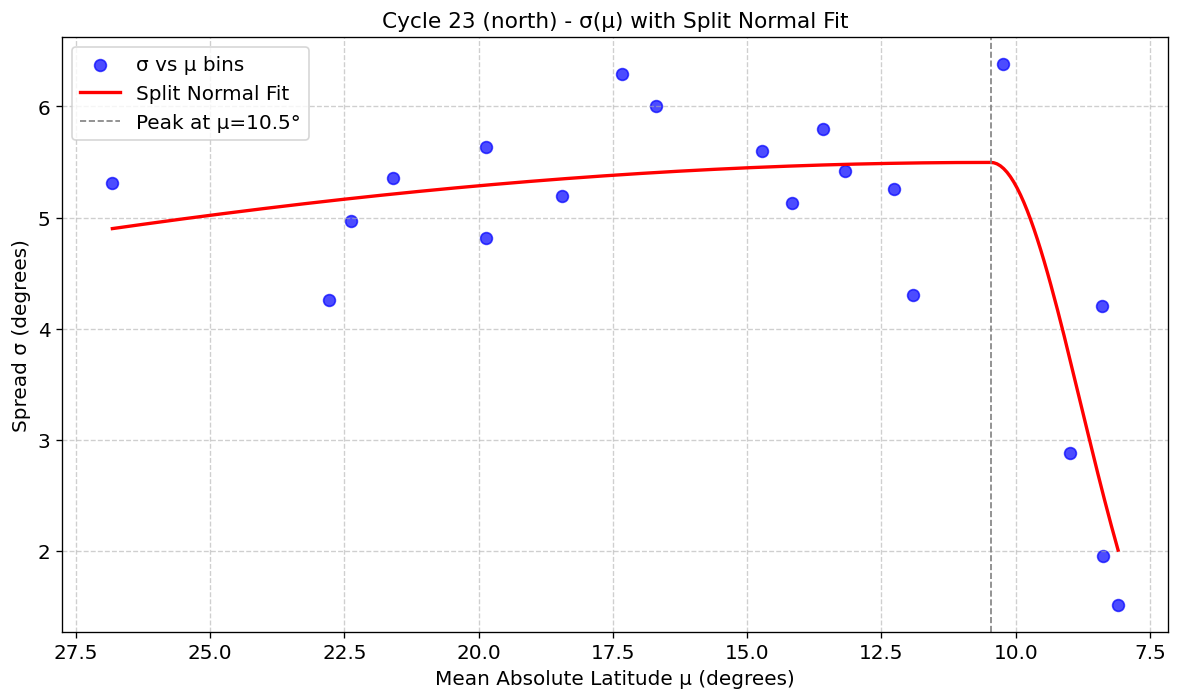

In [31]:
# adding the curve fit for task 15
from scipy.optimize import curve_fit

def split_normal_mu(mu_val, A, mu0, s_L, s_R):
    """
    Split normal (bi-normal / asymmetric Gaussian) function for sigma(mu).

    Parameters
    ----------
    mu_val : Mean absolute latitude values (x-axis).
    A      : peak sigma value (degrees)
    mu0    : peak location (mean absolute latitude)
    s_L    : left Gaussian width (larger -> gentler rise)
    s_R    : right Gaussian width (smaller -> steeper fall)
    """
    return np.where(mu_val < mu0,
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_R) ** 2))

# Initial guess for the parameters [A, mu0, s_L, s_R]
# A: peak sigma, guess from bin_sigma.max()
# mu0: peak mu, guess from bin_mu at bin_sigma.argmax()
# s_L, s_R: widths, often a few degrees
p0_sn_mu = [bin_sigma.max(), bin_mu[np.argmax(bin_sigma)], 5.0, 5.0]

# Perform the curve fit
try:
    popt_sn_mu, pcov_sn_mu = curve_fit(split_normal_mu, bin_mu, bin_sigma, p0=p0_sn_mu, maxfev=10000)
    A_sn_mu, mu0_sn_mu, sL_sn_mu, sR_sn_mu = popt_sn_mu

    print(f"Split Normal Fit for \u03c3(\u03bc) (Cycle {cycle_number}, {hemisphere}):")
    print(f"  A (peak spread): {A_sn_mu:.2f}°")
    print(f"  \u03bc₀ (peak latitude): {mu0_sn_mu:.2f}°")
    print(f"  s_L (left width): {sL_sn_mu:.2f} yr")
    print(f"  s_R (right width): {sR_sn_mu:.2f} yr")

    # Plot the fit
    mu_grid = np.linspace(bin_mu.min(), bin_mu.max(), 300)
    sigma_fit_curve = split_normal_mu(mu_grid, A_sn_mu, mu0_sn_mu, sL_sn_mu, sR_sn_mu)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(bin_mu, bin_sigma, color='blue', s=50, alpha=0.7, label='σ vs μ bins')
    ax.plot(mu_grid, sigma_fit_curve, color='red', linewidth=2, label='Split Normal Fit')
    ax.axvline(mu0_sn_mu, color='gray', linestyle='--', linewidth=1, label=f'Peak at μ={mu0_sn_mu:.1f}°')

    ax.set_xlabel('Mean Absolute Latitude μ (degrees)')
    ax.set_ylabel('Spread σ (degrees)')
    ax.set_title(f'Cycle {cycle_number} ({hemisphere}) - σ(μ) with Split Normal Fit')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.invert_xaxis() # Reverse the x-axis as per Task 14 hint
    plt.tight_layout()
    plt.show()

except RuntimeError as e:
    print(f"Failed to perform curve_fit: {e}")
    print("Consider adjusting initial parameter guesses (p0).")

## 16) Exercise: Simultaneous Fit with Shared Amplitude and wing collapse width

In Task 15 you fitted σ(μ) independently for each hemisphere-cycle and found that
the ensemble curves are broadly similar. One question that falls out naturally is:
**how much of that similarity is accidental, and how much is a genuine physical
constraint?**

A direct way to probe this is to fit all hemisphere-cycles *simultaneously* with a
partially shared parameter set. Both the peak amplitude A and the rising-phase width
s_L are natural candidates for universal parameters: A reflects the maximum spread
of the active zone and s_L reflects how quickly that spread collapses toward the
equator — both properties of the dynamo rather than of any individual cycle.

If you use the split gaussian fit, the model is therefore:

- **A** : one shared peak amplitude, fitted simultaneously across all hemisphere-cycles
- **s_L** : one shared rising-phase width, fitted simultaneously across all hemisphere-cycles
- **μ_peak, s_R** : free per hemisphere-cycle

**Task:**

- Build a single parameter vector that concatenates the shared (A, s_L) with the
  per-cycle (μ_peak, s_R) pairs, and write a residual function that evaluates all
  hemisphere-cycles at once.
- Fit using `scipy.optimize.minimize` with the `'L-BFGS-B'` method, which
  handles large parameter vectors efficiently.
- Compare the RMSE of this fit against the independent fits from Task 15.
  Does enforcing shared A and s_L degrade the fit significantly?
- Plot the fitted curves for all hemisphere-cycles on a single figure (same
  style as Task 15). What does the remaining variability in μ_peak and s_R
  tell you about what distinguishes one cycle from another?


Split Normal Fit for σ(μ) (Cycle 23, north):
  A (peak spread): 5.50°
  μ₀ (peak latitude): 10.46°
  s_L (left width): -1.67 yr
  s_R (right width): 34.21 yr


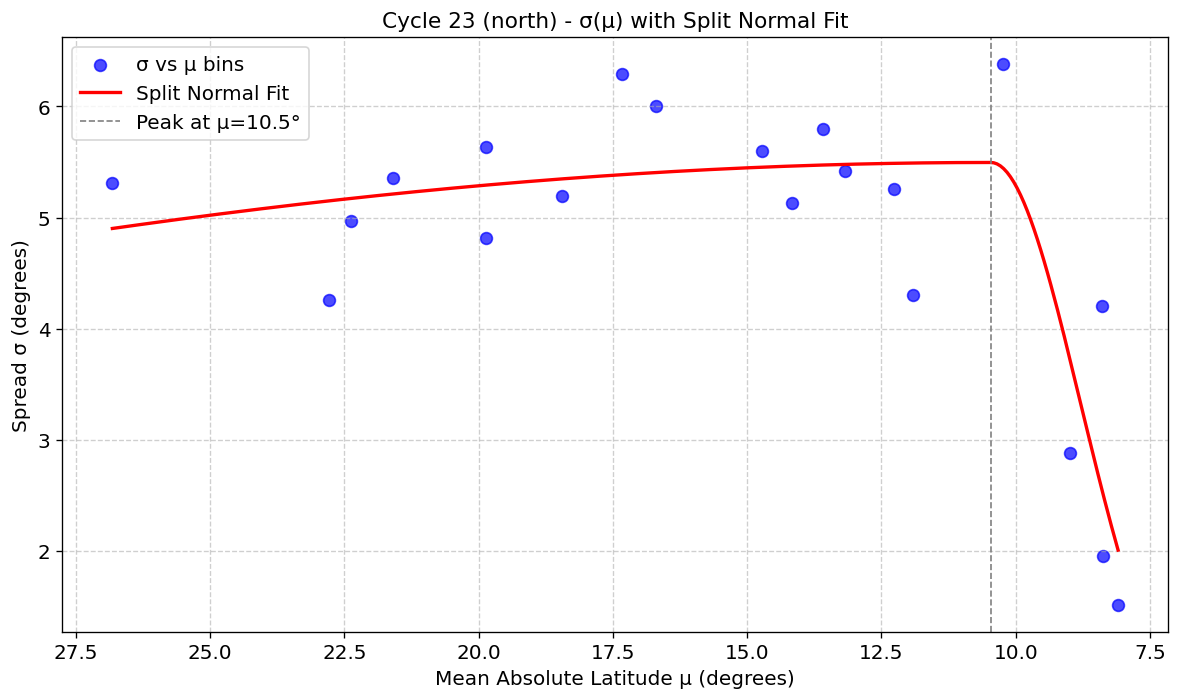

In [32]:
# Put your code for Task 16 here

# adding the curve fit for task 15
from scipy.optimize import curve_fit

def split_normal_mu(mu_val, A, mu0, s_L, s_R):
    """
    Split normal (bi-normal / asymmetric Gaussian) function for sigma(mu).

    Parameters
    ----------
    mu_val : Mean absolute latitude values (x-axis).
    A      : peak sigma value (degrees)
    mu0    : peak location (mean absolute latitude)
    s_L    : left Gaussian width (larger -> gentler rise)
    s_R    : right Gaussian width (smaller -> steeper fall)
    """
    return np.where(mu_val < mu0,
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_R) ** 2))

# Initial guess for the parameters [A, mu0, s_L, s_R]
# A: peak sigma, guess from bin_sigma.max()
# mu0: peak mu, guess from bin_mu at bin_sigma.argmax()
# s_L, s_R: widths, often a few degrees
p0_sn_mu = [bin_sigma.mean(), bin_mu[np.argmax(bin_sigma)], 5.0, 5.0]

# Perform the curve fit
try:
    popt_sn_mu, pcov_sn_mu = curve_fit(split_normal_mu, bin_mu, bin_sigma, p0=p0_sn_mu, maxfev=10000)
    A_sn_mu, mu0_sn_mu, sL_sn_mu, sR_sn_mu = popt_sn_mu

    print(f"Split Normal Fit for \u03c3(\u03bc) (Cycle {cycle_number}, {hemisphere}):")
    print(f"  A (peak spread): {A_sn_mu:.2f}°")
    print(f"  \u03bc₀ (peak latitude): {mu0_sn_mu:.2f}°")
    print(f"  s_L (left width): {sL_sn_mu:.2f} yr")
    print(f"  s_R (right width): {sR_sn_mu:.2f} yr")

    # Plot the fit
    mu_grid = np.linspace(bin_mu.min(), bin_mu.max(), 300)
    sigma_fit_curve = split_normal_mu(mu_grid, A_sn_mu, mu0_sn_mu, sL_sn_mu, sR_sn_mu)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(bin_mu, bin_sigma, color='blue', s=50, alpha=0.7, label='σ vs μ bins')
    ax.plot(mu_grid, sigma_fit_curve, color='red', linewidth=2, label='Split Normal Fit')
    ax.axvline(mu0_sn_mu, color='gray', linestyle='--', linewidth=1, label=f'Peak at μ={mu0_sn_mu:.1f}°')

    ax.set_xlabel('Mean Absolute Latitude μ (degrees)')
    ax.set_ylabel('Spread σ (degrees)')
    ax.set_title(f'Cycle {cycle_number} ({hemisphere}) - σ(μ) with Split Normal Fit')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.invert_xaxis() # Reverse the x-axis as per Task 14 hint
    plt.tight_layout()
    plt.show()

except RuntimeError as e:
    print(f"Failed to perform curve_fit: {e}")
    print("Consider adjusting initial parameter guesses (p0).")

Collected binned data for 26 hemisphere-cycles.
Initial parameters vector length: 54
Performing simultaneous fit...

Simultaneous fit successful!
Universal A (peak spread): 6.28°
Universal s_L (rising-phase width): 8.35 yr
Global RMSE for shared A, s_L fit: 0.924°


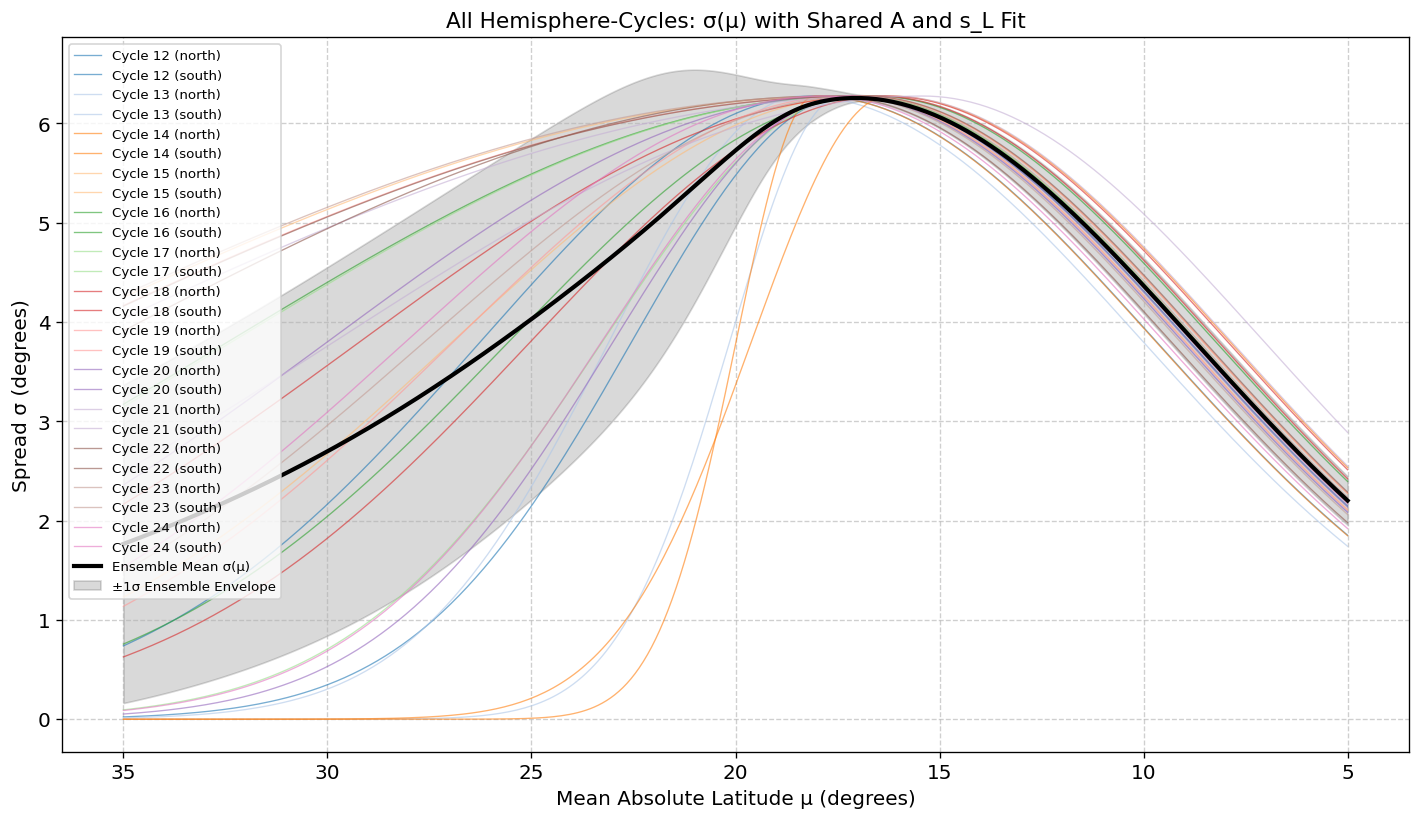

In [38]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt # Import plt
import matplotlib.cm as cm # Import cm

def split_normal_mu(mu_val, A, mu0, s_L, s_R):
    return np.where(mu_val < mu0,
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((mu_val - mu0) / s_R) ** 2))

# --- 1. Collect all binned (mu_bin, sigma_bin) data from all hemisphere-cycles ---
# This part needs to re-run the binning process for all relevant cycles,
# similar to how it was done in Task 15, but collecting the binned_mu and binned_sigma.

all_cycle_data = []

# Re-using parameters from previous tasks
N_bins = 20
min_obs_per_bin = 10
min_obs_per_cycle = 50

# Assuming `processed_df` and `relevant_cycles` are available from previous cells
# And `t0_lookup` from Task 9 for the original t0 to get tau_refined

for cycle_num in relevant_cycles:
    for hemi in ["north", "south"]:
        # Ensure we have a refined t0 for this cycle-hemisphere pair
        if (cycle_num, hemi) not in refined_t0_lookup:
            continue

        mask = (processed_df["CYCLE"] == cycle_num) & (processed_df["hemisphere"] == hemi) & processed_df["tau_refined"].notna()
        df_cyc_hemi = processed_df[mask].copy()

        if df_cyc_hemi.empty or len(df_cyc_hemi) < min_obs_per_cycle:
            continue

        tau_min_cycle = df_cyc_hemi['tau_refined'].min()
        tau_max_cycle = df_cyc_hemi['tau_refined'].max()

        if np.isnan(tau_min_cycle) or np.isnan(tau_max_cycle):
            continue

        tau_bins = np.linspace(tau_min_cycle, tau_max_cycle, N_bins + 1)

        cycle_bin_mu = []
        cycle_bin_sigma = []

        for i in range(N_bins):
            bin_mask = (df_cyc_hemi['tau_refined'] >= tau_bins[i]) & (df_cyc_hemi['tau_refined'] < tau_bins[i + 1])
            lats_in_bin = df_cyc_hemi.loc[bin_mask, 'abs_latitude'].values

            if len(lats_in_bin) >= min_obs_per_bin:
                mu_fit, sigma_fit = norm.fit(lats_in_bin)
                cycle_bin_mu.append(mu_fit)
                cycle_bin_sigma.append(sigma_fit)

        if len(cycle_bin_mu) > 0:
            all_cycle_data.append({
                'cycle': cycle_num,
                'hemisphere': hemi,
                'bin_mu': np.array(cycle_bin_mu),
                'bin_sigma': np.array(cycle_bin_sigma)
            })

print(f"Collected binned data for {len(all_cycle_data)} hemisphere-cycles.")

# --- 2. Define a single parameter vector and residual function ---

# Initial guesses for shared parameters (A, s_L)
initial_A = np.nanmean([d['bin_sigma'].max() for d in all_cycle_data if len(d['bin_sigma']) > 0])
initial_sL = np.nanmean([np.std(d['bin_mu']) for d in all_cycle_data if len(d['bin_mu']) > 0]) # rough guess

if np.isnan(initial_A):
    initial_A = 6.0 # Fallback
if np.isnan(initial_sL):
    initial_sL = 5.0 # Fallback

# Initial guesses for per-cycle parameters (mu0, s_R)
initial_per_cycle_params = []
for data_item in all_cycle_data:
    bm = data_item['bin_mu']
    bs = data_item['bin_sigma']
    if len(bm) > 0 and len(bs) > 0:
        mu0_guess = bm[np.argmax(bs)] if len(bs) > 0 else np.mean(bm)
        sR_guess = np.std(bm) # Rough guess
    else:
        mu0_guess = 15.0
        sR_guess = 5.0
    initial_per_cycle_params.extend([mu0_guess, sR_guess])

# Combine into a single parameter vector
# p = [A, s_L, mu0_1, sR_1, mu0_2, sR_2, ...]
initial_params = [initial_A, initial_sL] + initial_per_cycle_params

# Objective function to minimize (sum of squared residuals for all cycles)
def objective(params):
    A_shared = params[0]
    sL_shared = params[1]
    per_cycle_params = params[2:]

    total_residuals_sq = 0
    param_idx = 0

    for data_item in all_cycle_data:
        bin_mu = data_item['bin_mu']
        bin_sigma = data_item['bin_sigma']

        if len(bin_mu) == 0 or len(bin_sigma) == 0:
            continue

        mu0_cycle = per_cycle_params[param_idx]
        sR_cycle = per_cycle_params[param_idx + 1]

        # Ensure sL_shared and sR_cycle are positive and non-zero to prevent division by zero or invalid exp arguments.
        # Bounds already define (0.1, 20.0) for sL and sR, so this should be fine.
        model_sigma = split_normal_mu(bin_mu, A_shared, mu0_cycle, sL_shared, sR_cycle)
        total_residuals_sq += np.sum((bin_sigma - model_sigma)**2)

        param_idx += 2

    return total_residuals_sq

# --- 3. Fit using scipy.optimize.minimize ---
print(f"Initial parameters vector length: {len(initial_params)}")
print("Performing simultaneous fit...")

# Bounds for parameters (optional but recommended for stability)
# A_shared: [1, 15]
# sL_shared: [0.1, 20]
# mu0_cycle: [5, 40] (for each cycle)
# sR_cycle: [0.1, 20] (for each cycle)

bounds = [(1.0, 15.0), (0.1, 20.0)] # Bounds for A_shared, sL_shared
for _ in range(len(all_cycle_data)):
    bounds.extend([(5.0, 40.0), (0.1, 20.0)]) # Bounds for mu0_cycle, sR_cycle


result = minimize(objective, initial_params, method='L-BFGS-B', bounds=bounds, options={'maxiter': 100000, 'maxfun': 200000}) # Increased maxiter and maxfun

# Initialize fitted_results outside the if block to prevent NameError
fitted_results = []

if result.success:
    fitted_params = result.x
    A_universal = fitted_params[0]
    sL_universal = fitted_params[1]
    per_cycle_fitted_params = fitted_params[2:]

    print("\nSimultaneous fit successful!")
    print(f"Universal A (peak spread): {A_universal:.2f}°")
    print(f"Universal s_L (rising-phase width): {sL_universal:.2f} yr")

    # Store fitted parameters for each cycle
    param_idx = 0
    for data_item in all_cycle_data:
        mu0_fitted = per_cycle_fitted_params[param_idx]
        sR_fitted = per_cycle_fitted_params[param_idx + 1]
        fitted_results.append({
            'cycle': data_item['cycle'],
            'hemisphere': data_item['hemisphere'],
            'A_universal': A_universal,
            'sL_universal': sL_universal,
            'mu0': mu0_fitted,
            'sR': sR_fitted
        })
        param_idx += 2

    # Calculate global RMSE
    global_rmse = np.sqrt(result.fun / sum(len(d['bin_sigma']) for d in all_cycle_data))
    print(f"Global RMSE for shared A, s_L fit: {global_rmse:.3f}°")

    # --- Plotting the results (as required by Task 16) ---

    # Common mu grid for evaluation
    mu_grid_common = np.linspace(5, 35, 300) # Spanning typical Spörer zone

    fig, ax = plt.subplots(figsize=(12, 7))

    # Use a colormap for individual cycles
    # Updated: Use plt.colormaps.get_cmap instead of cm.get_cmap
    plot_cmap = plt.colormaps.get_cmap("tab20")
    cycle_color_map = {cyc: plot_cmap(i) for i, cyc in enumerate(relevant_cycles)}

    all_fitted_sigma_curves = []

    for res in fitted_results:
        cycle_num = res['cycle']
        hemi = res['hemisphere']
        mu0 = res['mu0']
        sR = res['sR']

        fitted_curve = split_normal_mu(mu_grid_common, A_universal, mu0, sL_universal, sR)
        ax.plot(mu_grid_common, fitted_curve,
                color=cycle_color_map[cycle_num], linewidth=0.8, alpha=0.6,
                label=f"Cycle {int(cycle_num)} ({hemi})")
        all_fitted_sigma_curves.append(fitted_curve)

    # Calculate and plot pointwise mean and std envelope
    all_fitted_sigma_curves = np.array(all_fitted_sigma_curves)
    mean_sigma_curve = np.nanmean(all_fitted_sigma_curves, axis=0)
    std_sigma_curve = np.nanstd(all_fitted_sigma_curves, axis=0)

    ax.plot(mu_grid_common, mean_sigma_curve, color='black', linewidth=2.5, label='Ensemble Mean σ(μ)')
    ax.fill_between(mu_grid_common, mean_sigma_curve - std_sigma_curve, mean_sigma_curve + std_sigma_curve,
                     color='black', alpha=0.15, label='±1σ Ensemble Envelope')

    # Add raw binned data for context (can make plot very busy, optional)
    # for data_item in all_cycle_data:
    #     ax.scatter(data_item['bin_mu'], data_item['bin_sigma'], s=10, alpha=0.1, color='gray')

    ax.set_xlabel('Mean Absolute Latitude μ (degrees)')
    ax.set_ylabel('Spread σ (degrees)')
    ax.set_title('All Hemisphere-Cycles: σ(μ) with Shared A and s_L Fit')
    ax.invert_xaxis() # Reverse x-axis
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

else:
    print(f"Simultaneous fit failed: {result.message}")
    A_universal = np.nan
    sL_universal = np.nan